In [6]:
man_utd_source = pd.read_excel("Man_Utd_22-25.xlsx",parse_dates=["Date"],date_format="%d-%m-%Y")

In [11]:
man_utd_source.set_index(["Rk"])

,Player,Date,Age,Nation,Team,Venue,Opp,Comp,Result,Start,Min,Gls,Ast,G+A,G-PK,PK,PKatt,PKm,Pos.
Rk,,,,,,,,,,,,,,,,,,,
1,Altay Bayandir,2025-05-25 00:00:00,27-041,TUR,Manchester Utd,Home,Aston Villa,Premier League,W 2-0,Y,90.0,0,0,0,0,0,0,0,GK
2,Chidozie Obi-Martin,2025-05-25 00:00:00,17-177,DEN,Manchester Utd,Home,Aston Villa,Premier League,W 2-0,N,10.0,0,0,0,0,0,0,0,FW
3,Rasmus Hojlund,2025-05-25 00:00:00,22-110,DEN,Manchester Utd,Home,Aston Villa,Premier League,W 2-0,Y,80.0,0,0,0,0,0,0,0,FW
4,Casemiro,2025-05-25 00:00:00,33-091,BRA,Manchester Utd,Home,Aston Villa,Premier League,W 2-0,Y,90.0,0,0,0,0,0,0,0,MF
5,Bruno Fernandes,2025-05-25 00:00:00,30-259,POR,Manchester Utd,Home,Aston Villa,Premier League,W 2-0,Y,90.0,0,1,1,0,0,0,0,MF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2638,Harry Maguire,2022-08-07 00:00:00,29-155,ENG,Manchester Utd,Home,Brighton,Premier League,L 1-2,Y,90.0,0,0,0,0,0,0,0,DF
2639,Scott McTominay,2022-08-07 00:00:00,25-242,SCO,Manchester Utd,Home,Brighton,Premier League,L 1-2,Y,77.0,0,0,0,0,0,0,0,MF
2640,Diogo Dalot,2022-08-07 00:00:00,23-142,POR,Manchester Utd,Home,Brighton,Premier League,L 1-2,Y,90.0,0,0,0,0,0,0,0,DF


In [12]:
man_utd_source["Date"] = pd.to_datetime(man_utd_source["Date"])

In [13]:
man_utd_source["Min"] = pd.to_numeric(man_utd_source["Min"], errors="coerce")

In [14]:
man_utd_source["Comp"] = man_utd_source["Comp"].astype("category")

In [18]:
man_utd_source["Start"] = man_utd_source["Start"].astype("bool")

In [41]:
man_utd_source[man_utd_source["Player"] == "Charlie McNeill"]

,Rk,Player,Date,Age,Nation,Team,Venue,Opp,Comp,Result,Start,Min,Gls,Ast,G+A,G-PK,PK,PKatt,PKm,Pos.
2550,2551,Charlie McNeill,2022-09-08,18-364,ENG,Manchester Utd,Home,Real Sociedad,Europa League,L 0-1,True,8.0,0,0,0,0,0,0,0,DF


In [19]:
man_utd_source.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2642 entries, 0 to 2641
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Rk      2642 non-null   int64         
 1   Player  2642 non-null   object        
 2   Date    2642 non-null   datetime64[ns]
 3   Age     2642 non-null   object        
 4   Nation  2642 non-null   object        
 5   Team    2642 non-null   object        
 6   Venue   2642 non-null   object        
 7   Opp     2642 non-null   object        
 8   Comp    2642 non-null   category      
 9   Result  2642 non-null   object        
 10  Start   2642 non-null   bool          
 11  Min     2641 non-null   float64       
 12  Gls     2642 non-null   int64         
 13  Ast     2642 non-null   int64         
 14  G+A     2642 non-null   int64         
 15  G-PK    2642 non-null   int64         
 16  PK      2642 non-null   int64         
 17  PKatt   2642 non-null   int64         
 18  PKm     

In [25]:
man_utd_source[man_utd_source["Min"].isna()]

,Rk,Player,Date,Age,Nation,Team,Venue,Opp,Comp,Result,Start,Min,Gls,Ast,G+A,G-PK,PK,PKatt,PKm,Pos.
31,32,Jonny Evans,2025-05-21,37-138,NIR,Manchester Utd,Neutral,Tottenham,Europa League,L 0-1,True,NaN,0,0,0,0,0,0,0,DF


In [26]:
man_utd_source.loc[man_utd_source["Min"].isna(),"Min"] = 0

In [27]:
man_utd_source[man_utd_source["Min"].isna()]

,Rk,Player,Date,Age,Nation,Team,Venue,Opp,Comp,Result,Start,Min,Gls,Ast,G+A,G-PK,PK,PKatt,PKm,Pos.


### Get Match Dates and Player details

In [28]:
match_dates = man_utd_source["Date"].drop_duplicates().sort_values().tolist()

In [29]:
match_dates

[Timestamp('2022-08-07 00:00:00'),
 Timestamp('2022-08-13 00:00:00'),
 Timestamp('2022-08-22 00:00:00'),
 Timestamp('2022-08-27 00:00:00'),
 Timestamp('2022-09-01 00:00:00'),
 Timestamp('2022-09-04 00:00:00'),
 Timestamp('2022-09-08 00:00:00'),
 Timestamp('2022-09-15 00:00:00'),
 Timestamp('2022-10-02 00:00:00'),
 Timestamp('2022-10-06 00:00:00'),
 Timestamp('2022-10-09 00:00:00'),
 Timestamp('2022-10-13 00:00:00'),
 Timestamp('2022-10-16 00:00:00'),
 Timestamp('2022-10-19 00:00:00'),
 Timestamp('2022-10-22 00:00:00'),
 Timestamp('2022-10-27 00:00:00'),
 Timestamp('2022-10-30 00:00:00'),
 Timestamp('2022-11-03 00:00:00'),
 Timestamp('2022-11-06 00:00:00'),
 Timestamp('2022-11-10 00:00:00'),
 Timestamp('2022-11-13 00:00:00'),
 Timestamp('2022-12-21 00:00:00'),
 Timestamp('2022-12-27 00:00:00'),
 Timestamp('2022-12-31 00:00:00'),
 Timestamp('2023-01-03 00:00:00'),
 Timestamp('2023-01-06 00:00:00'),
 Timestamp('2023-01-10 00:00:00'),
 Timestamp('2023-01-14 00:00:00'),
 Timestamp('2023-01-

In [30]:
players = man_utd_source["Player"].drop_duplicates().tolist()

In [31]:
players

['Altay Bayandir',
 'Chidozie Obi-Martin',
 'Rasmus Hojlund',
 'Casemiro',
 'Bruno Fernandes',
 'Ayden Heaven',
 'Mason Mount',
 'Christian Eriksen',
 'Amad Diallo',
 'Noussair Mazraoui',
 'Kobbie Mainoo',
 'Harry Maguire',
 'Diogo Dalot',
 'Patrick Dorgu',
 'Victor Lindelof',
 'Jonny Evans',
 'Joshua Zirkzee',
 'Leny Yoro',
 'Alejandro Garnacho',
 'Luke Shaw',
 'Andrae Onana',
 'Manuel Ugarte Ribeiro',
 'Harry Amass',
 'Tyler Fredricson',
 'Matthijs de Ligt',
 'Toby Collyer',
 'Lisandro Martinez',
 'Tyrell Malacia',
 'Antony',
 'Marcus Rashford',
 'Ethan Wheatley',
 'Scott McTominay',
 'Facundo Pellistri',
 'Jadon Sancho',
 'Sofyan Amrabat',
 'Aaron Wan-Bissaka',
 'Raphael Varane',
 'Omari Forson',
 'Willy Kambwala',
 'Hannibal Mejbri',
 'Sergio Reguilion',
 'Daniel Gore',
 'Anthony Martial',
 'Donny van de Beek',
 'David de Gea',
 'Fred',
 'Wout Weghorst',
 'Marcel Sabitzer',
 'Anthony Elanga',
 'Tom Heaton',
 'Martin Dobravka',
 'Brandon Williams',
 'Cristiano Ronaldo',
 'Charlie Mc

In [32]:
calendar_index = pd.MultiIndex.from_product([players, match_dates], names=["Player", "Date"])
calendar_df = calendar_index.to_frame(index=False)

In [35]:
full_df = calendar_df.merge(man_utd_source,on=["Player","Date"], how="left")

In [36]:
full_df["Min"] = full_df["Min"].fillna(0)

In [44]:
for col in ["Pos.","Team"]:
    full_df[col] = full_df.groupby("Player")[col].ffill().bfill()

In [47]:
full_df

,Player,Date,Rk,Age,Nation,Team,Venue,Opp,Comp,Result,Start,Min,Gls,Ast,G+A,G-PK,PK,PKatt,PKm,Pos.
0,Altay Bayandir,2022-08-07,NaN,NaN,NaN,Manchester Utd,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GK
1,Altay Bayandir,2022-08-13,NaN,NaN,NaN,Manchester Utd,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GK
2,Altay Bayandir,2022-08-22,NaN,NaN,NaN,Manchester Utd,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GK
3,Altay Bayandir,2022-08-27,NaN,NaN,NaN,Manchester Utd,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GK
4,Altay Bayandir,2022-09-01,NaN,NaN,NaN,Manchester Utd,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9391,Charlie McNeill,2025-05-08,NaN,NaN,NaN,Manchester Utd,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DF
9392,Charlie McNeill,2025-05-11,NaN,NaN,NaN,Manchester Utd,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DF
9393,Charlie McNeill,2025-05-16,NaN,NaN,NaN,Manchester Utd,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DF
9394,Charlie McNeill,2025-05-21,NaN,NaN,NaN,Manchester Utd,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DF


In [48]:
full_df = full_df.sort_values(["Player","Date"])

In [49]:
full_df

,Player,Date,Rk,Age,Nation,Team,Venue,Opp,Comp,Result,Start,Min,Gls,Ast,G+A,G-PK,PK,PKatt,PKm,Pos.
6090,Aaron Wan-Bissaka,2022-08-07,NaN,NaN,NaN,Manchester Utd,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DF
6091,Aaron Wan-Bissaka,2022-08-13,NaN,NaN,NaN,Manchester Utd,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DF
6092,Aaron Wan-Bissaka,2022-08-22,2602.0,24-269,ENG,Manchester Utd,Home,Liverpool,Premier League,W 2-1,True,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DF
6093,Aaron Wan-Bissaka,2022-08-27,NaN,NaN,NaN,Manchester Utd,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DF
6094,Aaron Wan-Bissaka,2022-09-01,NaN,NaN,NaN,Manchester Utd,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8173,Wout Weghorst,2025-05-08,NaN,NaN,NaN,Manchester Utd,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FW
8174,Wout Weghorst,2025-05-11,NaN,NaN,NaN,Manchester Utd,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FW
8175,Wout Weghorst,2025-05-16,NaN,NaN,NaN,Manchester Utd,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FW
8176,Wout Weghorst,2025-05-21,NaN,NaN,NaN,Manchester Utd,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FW


In [64]:
full_df.to_excel("full_Df.xlsx")

In [75]:
# ensure sorted by Player and Date
full_df = full_df.sort_values(["Player","Date"]).reset_index(drop=True)

rolling_vals = []
for player, grp in full_df.groupby("Player"):
    grp = grp.set_index("Date").sort_index()
    # this is an array of length grp.shape[0]
    roll7 = grp["Min"].rolling("14D").sum().values
    rolling_vals.extend(roll7)

full_df["14D Rolling Avg"] = rolling_vals


In [77]:
rolling_vals = []
for player, grp in full_df.groupby("Player"):
    grp = grp.set_index("Date").sort_index()
    # this is an array of length grp.shape[0]
    roll7 = grp["Min"].rolling("7D").sum().values
    rolling_vals.extend(roll7)

full_df["7D Rolling Avg"] = rolling_vals

In [78]:
full_df

,Player,Date,Rk,Age,Nation,Team,Venue,Opp,Comp,Result,...,Gls,Ast,G+A,G-PK,PK,PKatt,PKm,Pos.,7D Rolling Avg,14D Rolling Avg
0,Aaron Wan-Bissaka,2022-08-07,NaN,NaN,NaN,Manchester Utd,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DF,0.0,0.0
1,Aaron Wan-Bissaka,2022-08-13,NaN,NaN,NaN,Manchester Utd,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DF,0.0,0.0
2,Aaron Wan-Bissaka,2022-08-22,2602.0,24-269,ENG,Manchester Utd,Home,Liverpool,Premier League,W 2-1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DF,5.0,5.0
3,Aaron Wan-Bissaka,2022-08-27,NaN,NaN,NaN,Manchester Utd,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DF,5.0,5.0
4,Aaron Wan-Bissaka,2022-09-01,NaN,NaN,NaN,Manchester Utd,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DF,0.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9391,Wout Weghorst,2025-05-08,NaN,NaN,NaN,Manchester Utd,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FW,0.0,0.0
9392,Wout Weghorst,2025-05-11,NaN,NaN,NaN,Manchester Utd,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FW,0.0,0.0
9393,Wout Weghorst,2025-05-16,NaN,NaN,NaN,Manchester Utd,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FW,0.0,0.0
9394,Wout Weghorst,2025-05-21,NaN,NaN,NaN,Manchester Utd,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FW,0.0,0.0


In [79]:
full_df.to_excel("full_Df.xlsx")

In [81]:
full_df = full_df.drop(columns= [
    "Rk", "Result", "Gls", "Ast", "G+A", "G-PK", "PK", "PKatt", "PKm",])

In [82]:
full_df

,Player,Date,Age,Nation,Team,Venue,Opp,Comp,Start,Min,Pos.,7D Rolling Avg,14D Rolling Avg
0,Aaron Wan-Bissaka,2022-08-07,NaN,NaN,Manchester Utd,NaN,NaN,NaN,NaN,0.0,DF,0.0,0.0
1,Aaron Wan-Bissaka,2022-08-13,NaN,NaN,Manchester Utd,NaN,NaN,NaN,NaN,0.0,DF,0.0,0.0
2,Aaron Wan-Bissaka,2022-08-22,24-269,ENG,Manchester Utd,Home,Liverpool,Premier League,True,5.0,DF,5.0,5.0
3,Aaron Wan-Bissaka,2022-08-27,NaN,NaN,Manchester Utd,NaN,NaN,NaN,NaN,0.0,DF,5.0,5.0
4,Aaron Wan-Bissaka,2022-09-01,NaN,NaN,Manchester Utd,NaN,NaN,NaN,NaN,0.0,DF,0.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9391,Wout Weghorst,2025-05-08,NaN,NaN,Manchester Utd,NaN,NaN,NaN,NaN,0.0,FW,0.0,0.0
9392,Wout Weghorst,2025-05-11,NaN,NaN,Manchester Utd,NaN,NaN,NaN,NaN,0.0,FW,0.0,0.0
9393,Wout Weghorst,2025-05-16,NaN,NaN,Manchester Utd,NaN,NaN,NaN,NaN,0.0,FW,0.0,0.0
9394,Wout Weghorst,2025-05-21,NaN,NaN,Manchester Utd,NaN,NaN,NaN,NaN,0.0,FW,0.0,0.0


In [83]:
full_df = full_df.drop(columns=['Age','Nation','Team'])

In [91]:
full_df[full_df["Start"] != True]

,Player,Date,Venue,Opp,Comp,Start,Min,Pos.,7D Rolling Avg,14D Rolling Avg
0,Aaron Wan-Bissaka,2022-08-07,NaN,NaN,NaN,NaN,0.0,DF,0.0,0.0
1,Aaron Wan-Bissaka,2022-08-13,NaN,NaN,NaN,NaN,0.0,DF,0.0,0.0
3,Aaron Wan-Bissaka,2022-08-27,NaN,NaN,NaN,NaN,0.0,DF,5.0,5.0
4,Aaron Wan-Bissaka,2022-09-01,NaN,NaN,NaN,NaN,0.0,DF,0.0,5.0
5,Aaron Wan-Bissaka,2022-09-04,NaN,NaN,NaN,NaN,0.0,DF,0.0,5.0
...,...,...,...,...,...,...,...,...,...,...
9391,Wout Weghorst,2025-05-08,NaN,NaN,NaN,NaN,0.0,FW,0.0,0.0
9392,Wout Weghorst,2025-05-11,NaN,NaN,NaN,NaN,0.0,FW,0.0,0.0
9393,Wout Weghorst,2025-05-16,NaN,NaN,NaN,NaN,0.0,FW,0.0,0.0
9394,Wout Weghorst,2025-05-21,NaN,NaN,NaN,NaN,0.0,FW,0.0,0.0


In [1]:
import pandas as pd
import numpy as np

full_df = pd.read_excel("Full_DF.xlsx")

In [2]:
full_df

,Unnamed: 0,Player,Date,Venue,Opp,Comp,Start,Min,Pos.,7D Rolling Avg,14D Rolling Avg,Fixture Count 5D,Fixture Congestion Flag,Injury
0,0,Aaron Wan-Bissaka,2022-08-07,NaN,NaN,NaN,NaN,0,DF,0,0,0,False,0
1,1,Aaron Wan-Bissaka,2022-08-13,NaN,NaN,NaN,NaN,0,DF,0,0,0,False,0
2,2,Aaron Wan-Bissaka,2022-08-22,Home,Liverpool,Premier League,N,5,DF,5,5,1,False,0
3,3,Aaron Wan-Bissaka,2022-08-27,NaN,NaN,NaN,NaN,0,DF,5,5,0,False,0
4,4,Aaron Wan-Bissaka,2022-09-01,NaN,NaN,NaN,NaN,0,DF,0,5,0,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9391,9391,Wout Weghorst,2025-05-08,NaN,NaN,NaN,NaN,0,FW,0,0,0,False,0
9392,9392,Wout Weghorst,2025-05-11,NaN,NaN,NaN,NaN,0,FW,0,0,0,False,0
9393,9393,Wout Weghorst,2025-05-16,NaN,NaN,NaN,NaN,0,FW,0,0,0,False,0
9394,9394,Wout Weghorst,2025-05-21,NaN,NaN,NaN,NaN,0,FW,0,0,0,False,0


In [5]:
full_df = full_df.drop(columns= [
    "Unnamed: 0"])

In [6]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9396 entries, 0 to 9395
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Player                   9396 non-null   object        
 1   Date                     9396 non-null   datetime64[ns]
 2   Venue                    2642 non-null   object        
 3   Opp                      2642 non-null   object        
 4   Comp                     2642 non-null   object        
 5   Start                    2642 non-null   object        
 6   Min                      9396 non-null   int64         
 7   Pos.                     9396 non-null   object        
 8   7D Rolling Avg           9396 non-null   int64         
 9   14D Rolling Avg          9396 non-null   int64         
 10  Fixture Count 5D         9396 non-null   int64         
 11  Fixture Congestion Flag  9396 non-null   bool          
 12  Injury                   9396 non-

In [7]:
rolling_counts = []

for player, grp in full_df.groupby("Player"):
    grp = grp.set_index("Date").sort_index()
    
    # Count matches played in the last 5D (non-zero minutes)
    count5 = grp["Min"].gt(0).rolling("5D").sum().values  # .gt(0) = played match
    rolling_counts.extend(count5)

# Assign as new column
full_df["Fixture Count 5D"] = rolling_counts

# Create congestion flag (2 or more matches in past 5 days)
full_df["Fixture Congestion Flag"] = full_df["Fixture Count 5D"] >= 2

In [8]:
full_df["Injury"] = 0

full_df.loc[
    (full_df["7D Rolling Avg"] > 250) &
    (full_df["Min"] == 0) &
    (full_df["Fixture Congestion Flag"]),
    "Injury"
] = 1

In [9]:
full_df["Injury"].value_counts()

Injury
0    9396
Name: count, dtype: int64

In [10]:
full_df.to_excel("Full_Df.xlsx")

In [11]:
full_df["Injury"] = 0

trigger_mask = (
    (full_df["7D Rolling Avg"] > 160) &     # short-term spike
    (full_df["14D Rolling Avg"] > 280) &    # sustained workload
    (full_df["Min"] == 0)                   # player missed the game
)

sampled = full_df[trigger_mask].sample(frac=0.4, random_state=42).index
full_df.loc[sampled, "Injury"] = 1


In [12]:
full_df["Injury"].value_counts()

Injury
0    9395
1       1
Name: count, dtype: int64

In [13]:
print((full_df["7D Rolling Avg"] > 160).sum())
print((full_df["14D Rolling Avg"] > 280).sum())
print(((full_df["7D Rolling Avg"] > 160) & (full_df["14D Rolling Avg"] > 280)).sum())
print(((full_df["7D Rolling Avg"] > 160) & (full_df["14D Rolling Avg"] > 280) & (full_df["Min"] == 0)).sum())

875
525
396
2


In [14]:
full_df["Injury"] = 0

trigger_mask = (
    (full_df["7D Rolling Avg"] > 100) & 
    (full_df["14D Rolling Avg"] > 180) &
    (full_df["Min"] == 0)
)

# Show how many rows this matches
print(trigger_mask.sum())


sampled = full_df[trigger_mask].sample(frac=0.5, random_state=42).index
full_df.loc[sampled, "Injury"] = 1

15


In [15]:
full_df["Injury"].value_counts()

Injury
0    9388
1       8
Name: count, dtype: int64

In [16]:
full_df["Pos."].value_counts()

Pos.
DF       3424
MF       2009
FW       1521
GK        870
FW,MF     780
MF,FW     496
MF,DF     213
DF,MF      67
DF,FW      11
FW,DF       5
Name: count, dtype: int64

In [20]:
full_df = full_df.rename(columns={"Pos." : "Position","Min":"Minutes","Opp":"Opponent"})

In [21]:
full_df["Position"].value_counts()

Position
DF       3424
MF       2009
FW       1521
GK        870
FW,MF     780
MF,FW     496
MF,DF     213
DF,MF      67
DF,FW      11
FW,DF       5
Name: count, dtype: int64

In [82]:
def Pos_adjust(x):
    if x == "FW,MF":
        return "FW"
    elif x == "MF,FW":
        return "MF"
    elif x == "MF,DF":
        return "MF"
    elif x == "DF,MF":
        return "DF"
    elif x == "DF,FW":
        return "DF"
    elif x == "FW,DF":
        return "FW"
    else:
        return x

In [24]:
full_df["Primary Position"] = full_df["Position"].apply(Pos_adjust)

In [25]:
full_df["Primary Position"].value_counts()

Primary Position
DF    3502
MF    2718
FW    2306
GK     870
Name: count, dtype: int64

In [26]:
full_df["Comp"].value_counts()

Comp
Premier League         1717
Europa League           417
FA Cup                  228
EFL Cup                 175
Champions League         89
FA Community Shield      16
Name: count, dtype: int64

In [18]:
full_df.to_excel("Full_Df.xlsx")

In [27]:
import numpy as np
import pandas as pd

df = full_df.copy()  # your current frame
df = df.sort_values(["Player","Date"]).reset_index(drop=True)

# --- 1) Adaptive thresholds from your data ---
p7_hi  = np.percentile(df["7D Rolling Avg"], 90)   # acute high
p7_med = np.percentile(df["7D Rolling Avg"], 80)

p14_hi  = np.percentile(df["14D Rolling Avg"], 90) # chronic high
p14_med = np.percentile(df["14D Rolling Avg"], 75)

# --- 2) “Missed” and “low involvement” flags ---
df["dnp"]   = (df["Minutes"] == 0)
df["cameo"] = (df["Minutes"] <= 15)
df["no_start"] = (df["Start"] != "Y")

# --- 3) Position load map (tune if you like) ---
pos_load = {
     "GK":2, "DF":3, "MF":5, "FW":4
}
df["PosLoad"] = df["Primary Position"].map(pos_load).fillna(3)

# --- 4) Competition intensity (edit list to your labels) ---
hi_comp = {"Premier League","Champions League","Europa League"}
df["CompHi"] = df["Comp"].isin(hi_comp)

# --- 5) Trigger families (boolean masks) ---
acute   = (df["7D Rolling Avg"]  >= p7_hi)  & (df["dnp"] | df["cameo"])
chronic = (df["14D Rolling Avg"] >= p14_hi) & (df["dnp"] | df["cameo"])
conges  = (df["Fixture Count 5D"] >= 2) & (df["7D Rolling Avg"] >= p7_med) & (df["no_start"] | df["cameo"])

# absence streak: two consecutive DNPs and prior 14D >= p14_med
df["prev_Min"] = df.groupby("Player")["Minutes"].shift(1).fillna(0)
streak = (df["dnp"] & (df["prev_Min"] == 0) & (df["14D Rolling Avg"] >= p14_med))

context = (df["CompHi"] & (df["PosLoad"] >= 4) & (df["dnp"] | df["cameo"]) &
           ((df["7D Rolling Avg"] >= p7_med) | (df["14D Rolling Avg"] >= p14_med)))

# Union of all candidates
candidates_mask = acute | chronic | conges | streak | context
candidates = df[candidates_mask].copy()

# Optional: score within the pool to sample the highest-risk ones
candidates["risk_score"] = (
    (df["7D Rolling Avg"] / (p7_hi+1e-6)).clip(0, 2) +
    (df["14D Rolling Avg"] / (p14_hi+1e-6)).clip(0, 2) +
    df["Fixture Count 5D"].clip(0, 3) * 0.5 +
    df["PosLoad"] * 0.5 +
    df["CompHi"].astype(int)
)

# --- 6) Pick a target number of positives (e.g., 200) ---
TARGET = 200
pool = candidates.sort_values("risk_score", ascending=False)

if len(pool) < TARGET:
    # if still low, relax: include (cameo or no_start) after p7_med/p14_med
    relaxed = df[
        ((df["7D Rolling Avg"] >= p7_med) | (df["14D Rolling Avg"] >= p14_med)) &
        (df["no_start"] | df["cameo"])
    ].copy()
    relaxed["risk_score"] = (
        (df["7D Rolling Avg"] / (p7_hi+1e-6)).clip(0, 2) +
        (df["14D Rolling Avg"] / (p14_hi+1e-6)).clip(0, 2) +
        df["Fixture Count 5D"].clip(0, 3) * 0.5 +
        df["PosLoad"] * 0.5 +
        df["CompHi"].astype(int)
    )
    pool = pd.concat([pool, relaxed], ignore_index=True).drop_duplicates(["Player","Date"])

# cap to TARGET
chosen = pool.head(TARGET).index

# --- 7) Write Injury labels ---
df["Injury"] = 0
df.loc[chosen, "Injury"] = 1

# clean temp cols
df.drop(columns=["dnp","cameo","no_start","prev_Min","CompHi","PosLoad"], inplace=True, errors="ignore")

print("Positives:", int(df["Injury"].sum()), "of", len(df))


Positives: 200 of 9396


In [28]:
df["Injury"].value_counts()

Injury
0    9196
1     200
Name: count, dtype: int64

In [30]:
df

,Player,Date,Venue,Opponent,Comp,Start,Minutes,Position,7D Rolling Avg,14D Rolling Avg,Fixture Count 5D,Fixture Congestion Flag,Injury,Primary Position
0,Aaron Wan-Bissaka,2022-08-07,NaN,NaN,NaN,NaN,0,DF,0,0,0.0,False,0,DF
1,Aaron Wan-Bissaka,2022-08-13,NaN,NaN,NaN,NaN,0,DF,0,0,0.0,False,0,DF
2,Aaron Wan-Bissaka,2022-08-22,Home,Liverpool,Premier League,N,5,DF,5,5,1.0,False,0,DF
3,Aaron Wan-Bissaka,2022-08-27,NaN,NaN,NaN,NaN,0,DF,5,5,0.0,False,0,DF
4,Aaron Wan-Bissaka,2022-09-01,NaN,NaN,NaN,NaN,0,DF,0,5,0.0,False,0,DF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9391,Wout Weghorst,2025-05-08,NaN,NaN,NaN,NaN,0,FW,0,0,0.0,False,0,FW
9392,Wout Weghorst,2025-05-11,NaN,NaN,NaN,NaN,0,FW,0,0,0.0,False,0,FW
9393,Wout Weghorst,2025-05-16,NaN,NaN,NaN,NaN,0,FW,0,0,0.0,False,0,FW
9394,Wout Weghorst,2025-05-21,NaN,NaN,NaN,NaN,0,FW,0,0,0.0,False,0,FW


In [33]:
df = df.drop(columns=["Position"])

In [35]:
df["Comp"].unique()

array([nan, 'Premier League', 'EFL Cup', 'FA Cup', 'Europa League',
       'Champions League', 'FA Community Shield'], dtype=object)

In [40]:
def Comp_int(x):
    if x in hi_comp:
        return 5
    elif x == "FA Cup":
        return 4
    elif x == "EFL Cup" or x == "FA Community Shield":
        return 3
    else:
        return 1

df["Comp Intensity"] = df["Comp"].apply(Comp_int)

In [41]:
df

,Player,Date,Venue,Opponent,Comp,Start,Minutes,7D Rolling Avg,14D Rolling Avg,Fixture Count 5D,Fixture Congestion Flag,Injury,Primary Position,Comp Intensity
0,Aaron Wan-Bissaka,2022-08-07,NaN,NaN,NaN,NaN,0,0,0,0.0,False,0,DF,1
1,Aaron Wan-Bissaka,2022-08-13,NaN,NaN,NaN,NaN,0,0,0,0.0,False,0,DF,1
2,Aaron Wan-Bissaka,2022-08-22,Home,Liverpool,Premier League,N,5,5,5,1.0,False,0,DF,5
3,Aaron Wan-Bissaka,2022-08-27,NaN,NaN,NaN,NaN,0,5,5,0.0,False,0,DF,1
4,Aaron Wan-Bissaka,2022-09-01,NaN,NaN,NaN,NaN,0,0,5,0.0,False,0,DF,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9391,Wout Weghorst,2025-05-08,NaN,NaN,NaN,NaN,0,0,0,0.0,False,0,FW,1
9392,Wout Weghorst,2025-05-11,NaN,NaN,NaN,NaN,0,0,0,0.0,False,0,FW,1
9393,Wout Weghorst,2025-05-16,NaN,NaN,NaN,NaN,0,0,0,0.0,False,0,FW,1
9394,Wout Weghorst,2025-05-21,NaN,NaN,NaN,NaN,0,0,0,0.0,False,0,FW,1


In [42]:
pos_load = {
     "GK":2, "DF":3, "MF":5, "FW":4
}
df["PosLoad"] = df["Primary Position"].map(pos_load).fillna(3)

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9396 entries, 0 to 9395
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Player                   9396 non-null   object        
 1   Date                     9396 non-null   datetime64[ns]
 2   Venue                    2642 non-null   object        
 3   Opponent                 2642 non-null   object        
 4   Comp                     2642 non-null   object        
 5   Start                    2642 non-null   object        
 6   Minutes                  9396 non-null   int64         
 7   7D Rolling Avg           9396 non-null   int64         
 8   14D Rolling Avg          9396 non-null   int64         
 9   Fixture Count 5D         9396 non-null   float64       
 10  Fixture Congestion Flag  9396 non-null   bool          
 11  Injury                   9396 non-null   int64         
 12  Primary Position         9396 non-

In [61]:
df = df.rename(columns={'PosLoad': 'Position Load Score'})

In [44]:
df.to_excel("Full_Df.xlsx")

In [75]:
import numpy as np
import pandas as pd

def _minmax(s):
    s = s.astype(float).fillna(0.0)
    lo, hi = s.min(), s.max()
    return (s - lo) / (hi - lo) if hi > lo else s*0

def boost_injuries(df,
                   target_total=400,           # <-- just change this
                   cooldown_days=12,           # <-- and/or this
                   min_minutes=60,             # <-- and these thresholds
                   thr_7d=170,
                   thr_14d=300,
                   random_state=42):
    """
    df columns expected: Player, Date (datetime64), Minutes, 7D Rolling Avg, 14D Rolling Avg,
                         Started (Y/N), Position Load Score, Injury (0/1 or NaN)
    Returns a copy of df with more Injury=1 labels.
    """
    rng = np.random.default_rng(random_state)
    out = df.copy()
    out['Injury'] = out['Injury'].fillna(0).astype(int)
    out = out.sort_values(['Player','Date'])

    # 1) Find easy, interpretable "risk" candidates
    mask = (
        (out['Minutes'].fillna(0) >= min_minutes) |
        (out['7D Rolling Avg'].fillna(0) >= thr_7d) |
        (out['14D Rolling Avg'].fillna(0) >= thr_14d)
    ) & (out['Injury'] != 1)

    cands = out.loc[mask].copy()

    # 2) Tiny risk score (all bounded to [0,1] so weights are intuitive)
    cands['risk'] = (
        0.40 * _minmax(cands['7D Rolling Avg']) +
        0.40 * _minmax(cands['14D Rolling Avg']) +
        0.10 * (cands['Start'].fillna('N').eq('Y')).astype(float) +
        0.10 * _minmax(cands['Position Load Score'])
    )

    # 3) Greedy pick with per-player cooldown
    cands = cands.sort_values(['risk','Date'], ascending=[False, True])
    picked_idx = []
    last_injury = {}  # per player last injury date
    cool = pd.Timedelta(days=cooldown_days)

    # Pre-fill counts so we know how many more we need
    already = int(out['Injury'].sum())
    need = max(0, int(target_total) - already)
    if need == 0:
        return out

    for i, row in cands.iterrows():
        p, d = row['Player'], row['Date']
        if p not in last_injury or (d - last_injury[p]) >= cool:
            picked_idx.append(i)
            last_injury[p] = d
            if len(picked_idx) >= need:
                break

    out.loc[picked_idx, 'Injury'] = 1
    return out


In [78]:
df = boost_injuries(df, target_total=400, cooldown_days=12,
                         min_minutes=60, thr_7d=170, thr_14d=300)

In [79]:
df["Injury"].value_counts()

Injury
0    9046
1     350
Name: count, dtype: int64

In [80]:
df[df["Injury"]== 1]

,Player,Date,Venue,Opponent,Comp,Start,Minutes,7D Rolling Avg,14D Rolling Avg,Fixture Count 5D,Fixture Congestion Flag,Injury,Primary Position,Comp Intensity,Position Load Score
31,Aaron Wan-Bissaka,2023-01-28,Home,Reading,FA Cup,Y,90,270,360,2.0,True,1,DF,4,3
37,Aaron Wan-Bissaka,2023-02-19,Home,Leicester City,Premier League,N,22,112,130,2.0,True,1,DF,5,3
39,Aaron Wan-Bissaka,2023-02-26,Home,Newcastle Utd,EFL Cup,N,45,111,223,2.0,True,1,DF,3,3
108,Aaron Wan-Bissaka,2024-04-27,Home,Burnley,Premier League,Y,90,300,300,2.0,True,1,DF,5,3
112,Aaron Wan-Bissaka,2024-05-19,Away,Brighton,Premier League,Y,90,180,356,2.0,True,1,DF,5,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9045,Victor Lindelof,2025-05-16,Away,Chelsea,Premier League,Y,90,129,224,1.0,False,1,DF,5,3
9153,Willy Kambwala,2024-04-13,Away,Bournemouth,Premier League,Y,90,180,205,1.0,False,1,DF,5,3
9262,Wout Weghorst,2023-03-01,Home,West Ham,FA Cup,Y,90,204,384,2.0,True,1,FW,4,4
9267,Wout Weghorst,2023-03-19,Home,Fulham,FA Cup,Y,90,180,313,2.0,True,1,FW,4,4


In [98]:
df.to_excel("Modified_DF.xlsx",index = False)

In [87]:
full_df = df.copy()

In [90]:
full_df = full_df.drop(columns=["Opponent"])

In [92]:
full_df.describe()

,Date,Minutes,7D Rolling Avg,14D Rolling Avg,Fixture Count 5D,Injury,Comp Intensity,Position Load Score
count,9396,9396.000000,9396.000000,9396.000000,9396.000000,9396.000000,9396.000000,9396.000000
mean,2024-01-05 01:47:35.172413952,18.506386,35.221690,60.430183,0.465943,0.037250,2.059813,3.731375
min,2022-08-07 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000
25%,2023-03-12 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,3.000000
50%,2023-12-20 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.000000
75%,2024-11-07 00:00:00,15.000000,57.000000,90.000000,1.000000,0.000000,4.000000,5.000000
max,2025-05-25 00:00:00,120.000000,300.000000,450.000000,2.000000,1.000000,5.000000,5.000000
std,NaN,33.851739,62.171359,103.742300,0.742828,0.189384,1.721120,0.979947


In [4]:
full_df.columns

Index(['Unnamed: 0', 'Player', 'Date', 'Venue', 'Opponent', 'Comp', 'Start',
       'Minutes', '7D Rolling Avg', '14D Rolling Avg', 'Fixture Count 5D',
       'Fixture Congestion Flag', 'Injury', 'Primary Position',
       'Comp Intensity', 'PosLoad'],
      dtype='object')

In [5]:
categorical_columns = ["Comp","Venue","Start"]

In [96]:
full_df[categorical_columns].dropna()

,Comp,Venue,Start
2,Premier League,Home,N
21,EFL Cup,Home,Y
22,Premier League,Home,Y
23,Premier League,Away,Y
24,Premier League,Home,Y
...,...,...,...
9278,Premier League,Away,Y
9279,Premier League,Home,N
9280,Premier League,Away,N
9282,Premier League,Home,N


In [8]:
full_df = full_df.dropna(axis= 0, subset=["Venue","Comp","Start"])

In [9]:
full_df = full_df.reset_index()

In [10]:
full_df = full_df.drop(columns=["index"])

In [11]:
full_df

,Player,Date,Venue,Opponent,Comp,Start,Minutes,7D Rolling Avg,14D Rolling Avg,Fixture Count 5D,Fixture Congestion Flag,Injury,Primary Position,Comp Intensity,Position Load Score
0,Aaron Wan-Bissaka,2022-08-22,Home,Liverpool,Premier League,N,5,5,5,1,False,0,DF,5,3
1,Aaron Wan-Bissaka,2022-12-21,Home,Burnley,EFL Cup,Y,71,71,71,1,False,0,DF,3,3
2,Aaron Wan-Bissaka,2022-12-27,Home,Nott'ham Forest,Premier League,Y,90,161,161,1,False,0,DF,5,3
3,Aaron Wan-Bissaka,2022-12-31,Away,Wolves,Premier League,Y,90,180,251,2,True,0,DF,5,3
4,Aaron Wan-Bissaka,2023-01-03,Home,Bournemouth,Premier League,Y,68,158,319,2,True,0,DF,5,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2637,Wout Weghorst,2023-05-07,Away,West Ham,Premier League,Y,56,63,83,2,True,0,FW,5,4
2638,Wout Weghorst,2023-05-13,Home,Wolves,Premier League,N,22,78,85,1,False,0,FW,5,4
2639,Wout Weghorst,2023-05-20,Away,Bournemouth,Premier League,N,34,34,112,1,False,0,FW,5,4
2640,Wout Weghorst,2023-05-28,Home,Fulham,Premier League,N,14,14,48,1,False,0,FW,5,4


In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt

In [6]:
full_df = pd.read_excel("Modified_DF.xlsx")

In [7]:
full_df

,Player,Date,Venue,Opponent,Comp,Start,Minutes,7D Rolling Avg,14D Rolling Avg,Fixture Count 5D,Fixture Congestion Flag,Injury,Primary Position,Comp Intensity,Position Load Score
0,Aaron Wan-Bissaka,2022-08-07,NaN,NaN,NaN,NaN,0,0,0,0,False,0,DF,1,3
1,Aaron Wan-Bissaka,2022-08-13,NaN,NaN,NaN,NaN,0,0,0,0,False,0,DF,1,3
2,Aaron Wan-Bissaka,2022-08-22,Home,Liverpool,Premier League,N,5,5,5,1,False,0,DF,5,3
3,Aaron Wan-Bissaka,2022-08-27,NaN,NaN,NaN,NaN,0,5,5,0,False,0,DF,1,3
4,Aaron Wan-Bissaka,2022-09-01,NaN,NaN,NaN,NaN,0,0,5,0,False,0,DF,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9391,Wout Weghorst,2025-05-08,NaN,NaN,NaN,NaN,0,0,0,0,False,0,FW,1,4
9392,Wout Weghorst,2025-05-11,NaN,NaN,NaN,NaN,0,0,0,0,False,0,FW,1,4
9393,Wout Weghorst,2025-05-16,NaN,NaN,NaN,NaN,0,0,0,0,False,0,FW,1,4
9394,Wout Weghorst,2025-05-21,NaN,NaN,NaN,NaN,0,0,0,0,False,0,FW,1,4


In [12]:
def get_season(date):
    year = date.year
    if date.month >= 8:  # from August, new season starts
        return f"{year}/{str(year+1)[-2:]}"
    else:  # Jan–July belong to the previous season
        return f"{year-1}/{str(year)[-2:]}"

full_df["Season"] = pd.to_datetime(full_df["Date"]).apply(get_season)

In [15]:
full_df

,Player,Date,Venue,Opponent,Comp,Start,Minutes,7D Rolling Avg,14D Rolling Avg,Fixture Count 5D,Fixture Congestion Flag,Injury,Primary Position,Comp Intensity,Position Load Score,Season
0,Aaron Wan-Bissaka,2022-08-22,Home,Liverpool,Premier League,N,5,5,5,1,False,0,DF,5,3,2022/23
1,Aaron Wan-Bissaka,2022-12-21,Home,Burnley,EFL Cup,Y,71,71,71,1,False,0,DF,3,3,2022/23
2,Aaron Wan-Bissaka,2022-12-27,Home,Nott'ham Forest,Premier League,Y,90,161,161,1,False,0,DF,5,3,2022/23
3,Aaron Wan-Bissaka,2022-12-31,Away,Wolves,Premier League,Y,90,180,251,2,True,0,DF,5,3,2022/23
4,Aaron Wan-Bissaka,2023-01-03,Home,Bournemouth,Premier League,Y,68,158,319,2,True,0,DF,5,3,2022/23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2637,Wout Weghorst,2023-05-07,Away,West Ham,Premier League,Y,56,63,83,2,True,0,FW,5,4,2022/23
2638,Wout Weghorst,2023-05-13,Home,Wolves,Premier League,N,22,78,85,1,False,0,FW,5,4,2022/23
2639,Wout Weghorst,2023-05-20,Away,Bournemouth,Premier League,N,34,34,112,1,False,0,FW,5,4,2022/23
2640,Wout Weghorst,2023-05-28,Home,Fulham,Premier League,N,14,14,48,1,False,0,FW,5,4,2022/23


In [22]:
full_df = full_df.drop(columns=["Player"])

In [23]:
full_df.to_excel("Modified_DF.xlsx")

In [30]:
full_df.dtypes`

Date                       datetime64[ns]
Venue                              object
Start                              object
Minutes                             int64
7D Rolling Avg                      int64
14D Rolling Avg                     int64
Fixture Count 5D                    int64
Fixture Congestion Flag              bool
Injury                              int64
Primary Position                   object
Comp Intensity                      int64
Position Load Score                 int64
Season                             object
dtype: object

In [32]:
print(full_df["Start"].value_counts())
print(full_df["Venue"].value_counts())

Start
Y    1915
N     727
Name: count, dtype: int64
Venue
Home       1363
Away       1203
Neutral      76
Name: count, dtype: int64


### Encoding time

### Train and Test split data first

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

In [34]:
# Features and target
X = full_df.drop(columns=["Injury", "Date"])
y = full_df["Injury"]

In [35]:
X.head()

,Venue,Start,Minutes,7D Rolling Avg,14D Rolling Avg,Fixture Count 5D,Fixture Congestion Flag,Primary Position,Comp Intensity,Position Load Score,Season
0,Home,N,5,5,5,1,False,DF,5,3,2022/23
1,Home,Y,71,71,71,1,False,DF,3,3,2022/23
2,Home,Y,90,161,161,1,False,DF,5,3,2022/23
3,Away,Y,90,180,251,2,True,DF,5,3,2022/23
4,Home,Y,68,158,319,2,True,DF,5,3,2022/23


In [36]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [37]:
# Feature groups
numeric_features = ["Minutes", "7D Rolling Avg", "14D Rolling Avg","Fixture Count 5D", "Comp Intensity", "Position Load Score"]

binary_features = ["Start", "Fixture Congestion Flag"]

categorical_features = ["Venue", "Primary Position", "Season"]

In [38]:
# Training data
# shape of input:
# The number or rows is the number of data points
# The number or columns is the number of features
print(X_train.shape)
# shape of output:
# The number or rows is the number of data points (should be the same as before!)
# The number or columns is the number of labels we want to predict
print(y_train.shape)

(2113, 11)
(2113,)


In [39]:
# Test data
# shape of input:
# The number or rows is the number of data points
# The number or columns is the number of features (should be the same as for the training!)
print(X_test.shape)
# shape of output:
# The number or rows is the number of data points (should be the same as before!)
# The number or columns is the number of labels we want to predict
print(y_test.shape)

(529, 11)
(529,)


In [ ]:
ct_log = ColumnTransformer(
    transformers= [
        (
            "Numeric", # --> name of the transformation
            StandardScaler(), # --> main function to apply
            numeric_features, #-->columns to apply it to (we can give more than one column at once!)
        ),
        (
            "Binary", # --> name of the transformation
            "passthrough", # --> main function to apply
            binary_features, #-->columns to apply it to (we can give more than one column at once!)
        ),
        (
            'ohe',
             OneHotEncoder(handle_unknown='ignore'),
             categorical_features
        ),
    ],
    remainder="passthrough", #--> what to do with the non-transformed columns. passthrough=keep them
    verbose_feature_names_out=False #--> this keeps columns names simple.
)

In [ ]:
clf_ = Pipeline(
        steps =[
            ('ct', ct_log),
            ('clf', LogisticRegression( multi_class='multinomial', max_iter=1000)),
      ]
    )

clf_.get_params()

In [41]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier

# ---------------------------
# 0) Prepare data
# ---------------------------
df = full_df.copy()

# Binary map: Start Y/N -> 1/0
df["Start"] = df["Start"].map({"Y": 1, "N": 0}).fillna(0).astype(int)
# Ensure congestion flag is 0/1
df["Fixture Congestion Flag"] = df["Fixture Congestion Flag"].fillna(0).astype(int)

# Drop date from features
df = df.drop(columns=["Date"])

# X/y
X = df.drop(columns=["Injury"])
y = df["Injury"].astype(int)

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# ---------------------------
# 1) Column groups & preprocessors
# ---------------------------
numeric_features = [
    "Minutes", "7D Rolling Avg", "14D Rolling Avg",
    "Fixture Count 5D", "Comp Intensity", "Position Load Score"
]
binary_features = ["Start", "Fixture Congestion Flag"]
categorical_features = ["Venue", "Primary Position", "Season"]

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
bin_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])  # keep 0/1 as-is
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, numeric_features),
    ("bin", bin_pipe, binary_features),
    ("cat", cat_pipe, categorical_features),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ---------------------------
# 2) Model zoo + hyperparameters
# ---------------------------
pipelines = {
    "logreg": Pipeline([("preprocess", preprocessor),
                        ("model", LogisticRegression(max_iter=500, class_weight="balanced", n_jobs=None))]),
    "rf":     Pipeline([("preprocess", preprocessor),
                        ("model", RandomForestClassifier(random_state=42, class_weight="balanced"))]),
    "gb":     Pipeline([("preprocess", preprocessor),
                        ("model", GradientBoostingClassifier(random_state=42))]),
    "hgb":    Pipeline([("preprocess", preprocessor),
                        ("model", HistGradientBoostingClassifier(random_state=42))]),
}

# Small, sane grids to start (expand if time allows)
param_grids = {
    "logreg": {
        "model__C": [0.1, 0.5, 1.0, 2.0, 5.0],
        "model__penalty": ["l2"],
        "model__solver": ["lbfgs", "liblinear"]
    },
    "rf": {
        "model__n_estimators": [200, 400, 800],
        "model__max_depth": [None, 10, 20, 40],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },
    "gb": {
        "model__n_estimators": [200, 400, 600],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [2, 3, 4],
        "model__subsample": [0.7, 0.85, 1.0]
    },
    "hgb": {
        "model__max_depth": [None, 6, 10],
        "model__learning_rate": [0.03, 0.06, 0.1],
        "model__max_leaf_nodes": [31, 63, 127],
        "model__l2_regularization": [0.0, 0.1, 1.0]
    },
}

# Primary scoring for imbalanced data (ROC-AUC + PR-AUC (average precision))
scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "f1": "f1",
    "recall": "recall",
    "precision": "precision"
}

results = {}

# ---------------------------
# 3) Grid/Random search per model
# ---------------------------
for name, pipe in pipelines.items():
    grid = param_grids[name]
    # Use RandomizedSearch for larger grids to speed up; GridSearch for small grids
    search = GridSearchCV(
        estimator=pipe,
        param_grid=grid,
        scoring=scoring,
        refit="pr_auc",            # refit to the metric you care most about on imbalance
        cv=cv,
        n_jobs=-1,
        verbose=1
    )
    search.fit(X_train, y_train)

    # Evaluate on test
    best = search.best_estimator_
    y_prob = best.predict_proba(X_test)[:, 1] if hasattr(best["model"], "predict_proba") else best.decision_function(X_test)
    y_pred = best.predict(X_test)

    results[name] = {
        "best_params": search.best_params_,
        "cv_best_scores": search.best_score_,
        "test_roc_auc": roc_auc_score(y_test, y_prob),
        "test_pr_auc": average_precision_score(y_test, y_prob),
        "report": classification_report(y_test, y_pred, digits=3)
    }

# ---------------------------
# 4) Show summary
# ---------------------------
for name, res in results.items():
    print(f"\n=== {name.upper()} ===")
    print("Best params:", res["best_params"])
    print(f"CV best (PR-AUC refit): {res['cv_best_scores']:.3f}")
    print(f"Test ROC-AUC: {res['test_roc_auc']:.3f}")
    print(f"Test PR-AUC : {res['test_pr_auc']:.3f}")
    print(res["report"])


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Fitting 5 folds for each of 81 candidates, totalling 405 fits

=== LOGREG ===
Best params: {'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
CV best (PR-AUC refit): 0.620
Test ROC-AUC: 0.829
Test PR-AUC : 0.545
              precision    recall  f1-score   support

           0      0.945     0.786     0.858       462
           1      0.317     0.687     0.434        67

    accuracy                          0.773       529
   macro avg      0.631     0.736     0.646       529
weighted avg      0.866     0.773     0.804       529


=== RF ===
Best params: {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 400}
CV best (PR-AUC refit): 0.815
Test ROC-AUC: 0.885
Test PR-AUC : 0.715
              precision    recall  f1-score   sup

## Adding more teams to the table

In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt

arsenal_source = pd.read_excel("Arsenal_22-25.xlsx",parse_dates=["Date"],date_format="%d-%m-%Y")

In [2]:
arsenal_source.set_index("Rk")

,Player,Date,Venue,Team,Opp,Comp,Result,Outcome,Start,Min,Pos.
Rk,,,,,,,,,,,
1,Declan Rice,2025-05-25 00:00:00,Away,Arsenal,Southampton,Premier League,W 2-1,W,Y,90,MF
2,Ben White,2025-05-25 00:00:00,Away,Arsenal,Southampton,Premier League,W 2-1,W,Y,90,DF
3,Leandro Trossard,2025-05-25 00:00:00,Away,Arsenal,Southampton,Premier League,W 2-1,W,N,28,FW
4,Gabriel Martinelli,2025-05-25 00:00:00,Away,Arsenal,Southampton,Premier League,W 2-1,W,Y,69,"FW,MF"
5,Oleksandr Zinchenko,2025-05-25 00:00:00,Away,Arsenal,Southampton,Premier League,W 2-1,W,Y,69,"DF,MF"
...,...,...,...,...,...,...,...,...,...,...,...
2390,Eddie Nketiah,2022-08-05 00:00:00,Away,Arsenal,Crystal Palace,Premier League,W 2-0,W,N,8,FW
2391,Gabriel Jesus,2022-08-05 00:00:00,Away,Arsenal,Crystal Palace,Premier League,W 2-0,W,Y,82,FW
2392,Bukayo Saka,2022-08-05 00:00:00,Away,Arsenal,Crystal Palace,Premier League,W 2-0,W,Y,90,FW


In [3]:
av_source = pd.read_excel("AV_22-25.xlsx",parse_dates=["Date"],date_format="%d-%m-%Y")

In [4]:
av_source.set_index("Rk")

,Player,Date,Team,Venue,Opp,Comp,Result,Outcome,Start,Min,Pos.
Rk,,,,,,,,,,,
1,Ezri Konsa,2025-05-25 00:00:00,Aston Villa,Away,Manchester Utd,Premier League,L 0-2,L,Y,90,DF
2,Donyell Malen,2025-05-25 00:00:00,Aston Villa,Away,Manchester Utd,Premier League,L 0-2,L,N,7,FW
3,Jacob Ramsey,2025-05-25 00:00:00,Aston Villa,Away,Manchester Utd,Premier League,L 0-2,L,N,28,"FW,MF"
4,Matty Cash,2025-05-25 00:00:00,Aston Villa,Away,Manchester Utd,Premier League,L 0-2,L,Y,90,DF
5,Morgan Rogers,2025-05-25 00:00:00,Aston Villa,Away,Manchester Utd,Premier League,L 0-2,L,Y,83,"FW,MF"
...,...,...,...,...,...,...,...,...,...,...,...
2333,Emiliano MartÃ­nez,2022-08-06 00:00:00,Aston Villa,Away,Bournemouth,Premier League,L 0-2,L,Y,90,GK
2334,John McGinn,2022-08-06 00:00:00,Aston Villa,Away,Bournemouth,Premier League,L 0-2,L,Y,90,"MF,FW"
2335,Ollie Watkins,2022-08-06 00:00:00,Aston Villa,Away,Bournemouth,Premier League,L 0-2,L,N,25,FW


In [5]:
everton_source = pd.read_excel("Everton_22-25.xlsx",parse_dates=["Date"],date_format="%d-%m-%Y")

In [6]:
everton_source.set_index("Rk")

,Player,Date,Venue,Team,Opp,Comp,Result,Outcome,Start,Min,Pos.
Rk,,,,,,,,,,,
1,Abdoulaye Doucoure,2025-05-25 00:00:00,Away,Everton,Newcastle Utd,Premier League,W 1-0,W,N,15,MF
2,Jake O'Brien,2025-05-25 00:00:00,Away,Everton,Newcastle Utd,Premier League,W 1-0,W,Y,90,DF
3,Vitaliy Mykolenko,2025-05-25 00:00:00,Away,Everton,Newcastle Utd,Premier League,W 1-0,W,Y,90,DF
4,Jordan Pickford,2025-05-25 00:00:00,Away,Everton,Newcastle Utd,Premier League,W 1-0,W,Y,90,GK
5,Carlos Alcaraz,2025-05-25 00:00:00,Away,Everton,Newcastle Utd,Premier League,W 1-0,W,Y,75,"FW,MF"
...,...,...,...,...,...,...,...,...,...,...,...
1617,Ben Godfrey,2022-08-06 00:00:00,Home,Everton,Chelsea,Premier League,L 0-1,L,Y,17,DF
1618,Ruben Vinagre,2022-08-06 00:00:00,Home,Everton,Chelsea,Premier League,L 0-1,L,N,21,"DF,MF"
1619,Dele Alli,2022-08-06 00:00:00,Home,Everton,Chelsea,Premier League,L 0-1,L,N,30,MF


In [7]:
arsenal_source[arsenal_source["Min"].isna()]

,Rk,Player,Date,Venue,Team,Opp,Comp,Result,Outcome,Start,Min,Pos.


In [8]:
everton_source[everton_source["Min"].isna()]

,Rk,Player,Date,Venue,Team,Opp,Comp,Result,Outcome,Start,Min,Pos.


In [9]:
av_source[av_source["Min"].isna()]

,Rk,Player,Date,Team,Venue,Opp,Comp,Result,Outcome,Start,Min,Pos.


In [10]:
arsenal_df = pd.DataFrame()
everton_df = pd.DataFrame()
av_df = pd.DataFrame()

In [11]:
	match_dates = arsenal_source["Date"].drop_duplicates().sort_values().tolist()
	players = arsenal_source["Player"].drop_duplicates().tolist()
	calendar_index = pd.MultiIndex.from_product([players, match_dates], names=["Player", "Date"])
	calendar_df = calendar_index.to_frame(index=False)
	arsenal_df = calendar_df.merge(arsenal_source,on=["Player","Date"], how="left")

In [12]:
	match_dates = everton_source["Date"].drop_duplicates().sort_values().tolist()
	players = everton_source["Player"].drop_duplicates().tolist()
	calendar_index = pd.MultiIndex.from_product([players, match_dates], names=["Player", "Date"])
	calendar_df = calendar_index.to_frame(index=False)
	everton_df = calendar_df.merge(everton_source,on=["Player","Date"], how="left")

In [13]:
	match_dates = av_source["Date"].drop_duplicates().sort_values().tolist()
	players = av_source["Player"].drop_duplicates().tolist()
	calendar_index = pd.MultiIndex.from_product([players, match_dates], names=["Player", "Date"])
	calendar_df = calendar_index.to_frame(index=False)
	av_df = calendar_df.merge(av_source,on=["Player","Date"], how="left")

In [14]:
av_df

,Player,Date,Rk,Team,Venue,Opp,Comp,Result,Outcome,Start,Min,Pos.
0,Ezri Konsa,2022-08-06 00:00:00,2323.0,Aston Villa,Away,Bournemouth,Premier League,L 0-2,L,Y,90.0,DF
1,Ezri Konsa,2022-08-13 00:00:00,2307.0,Aston Villa,Home,Everton,Premier League,W 2-1,W,N,1.0,DF
2,Ezri Konsa,2022-08-20 00:00:00,2293.0,Aston Villa,Away,Crystal Palace,Premier League,L 1-3,L,Y,90.0,DF
3,Ezri Konsa,2022-08-23 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Ezri Konsa,2022-08-28 00:00:00,2262.0,Aston Villa,Home,West Ham,Premier League,L 0-1,L,Y,90.0,DF
...,...,...,...,...,...,...,...,...,...,...,...,...
8619,Ludwig Augustinsson,2025-04-26 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8620,Ludwig Augustinsson,2025-05-03 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8621,Ludwig Augustinsson,2025-05-10 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8622,Ludwig Augustinsson,2025-05-16 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
arsenal_df[~arsenal_df["Venue"].isna()]

,Player,Date,Rk,Venue,Team,Opp,Comp,Result,Outcome,Start,Min,Pos.
49,Declan Rice,2023-08-06 00:00:00,1637.0,Neutral,Arsenal,Manchester City,FA Community Shield,D 1-1,D,Y,80.0,MF
50,Declan Rice,2023-08-12 00:00:00,1622.0,Home,Arsenal,Nott'ham Forest,Premier League,W 2-1,W,Y,90.0,MF
51,Declan Rice,2023-08-21 00:00:00,1607.0,Away,Arsenal,Crystal Palace,Premier League,W 1-0,W,Y,90.0,MF
52,Declan Rice,2023-08-26 00:00:00,1591.0,Home,Arsenal,Fulham,Premier League,D 2-2,D,Y,89.0,MF
53,Declan Rice,2023-09-03 00:00:00,1575.0,Home,Arsenal,Manchester Utd,Premier League,W 3-1,W,Y,90.0,MF
...,...,...,...,...,...,...,...,...,...,...,...,...
6846,Marquinhos,2022-10-06 00:00:00,2247.0,Home,Arsenal,BodÃ¸/Glimt,Europa League,W 3-0,W,Y,57.0,FW
6848,Marquinhos,2022-10-13 00:00:00,2218.0,Away,Arsenal,BodÃ¸/Glimt,Europa League,W 1-0,W,N,21.0,FW
6856,Marquinhos,2022-11-09 00:00:00,2094.0,Home,Arsenal,Brighton,EFL Cup,L 1-3,L,Y,61.0,MF
6861,Marquinhos,2023-01-09 00:00:00,2025.0,Away,Arsenal,Oxford United,FA Cup,W 3-0,W,N,9.0,"FW,MF"


In [16]:
everton_df

,Player,Date,Rk,Venue,Team,Opp,Comp,Result,Outcome,Start,Min,Pos.
0,Abdoulaye Doucoure,2022-08-06 00:00:00,1608.0,Home,Everton,Chelsea,Premier League,L 0-1,L,Y,90.0,MF
1,Abdoulaye Doucoure,2022-08-13 00:00:00,1593.0,Away,Everton,Aston Villa,Premier League,L 1-2,L,Y,34.0,MF
2,Abdoulaye Doucoure,2022-08-20 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Abdoulaye Doucoure,2022-08-27 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Abdoulaye Doucoure,2022-08-30 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
5353,Dele Alli,2025-04-26 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5354,Dele Alli,2025-05-03 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5355,Dele Alli,2025-05-10 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5356,Dele Alli,2025-05-18 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
everton_df["Min"] = everton_df["Min"].fillna(0)
av_df["Min"] = av_df["Min"].fillna(0)
arsenal_df["Min"] = arsenal_df["Min"].fillna(0)

In [18]:
for col in ["Pos.","Team"]:
    everton_df[col] = everton_df.groupby("Player")[col].ffill().bfill()

for col in ["Pos.","Team"]:
    av_df[col] = av_df.groupby("Player")[col].ffill().bfill()

for col in ["Pos.","Team"]:
    arsenal_df[col] = arsenal_df.groupby("Player")[col].ffill().bfill()

In [19]:
arsenal_df["Date"] = pd.to_datetime(arsenal_df["Date"])
everton_df["Date"] = pd.to_datetime(everton_df["Date"])
av_df["Date"] = pd.to_datetime(av_df["Date"])

In [20]:
team_dfs = [arsenal_df,everton_df,av_df]

In [24]:
arsenal_df = arsenal_df.sort_values(["Player","Date"]).reset_index(drop=True)
av_df = av_df.sort_values(["Player","Date"]).reset_index(drop=True)
everton_df = everton_df.sort_values(["Player","Date"]).reset_index(drop=True)


In [26]:
rolling_vals = []
for player, grp in arsenal_df.groupby("Player"):
    grp = grp.set_index("Date").sort_index()
    # this is an array of length grp.shape[0]
    roll7 = grp["Min"].rolling("14D").sum().values
    rolling_vals.extend(roll7)

arsenal_df["14D Rolling Avg"] = rolling_vals
    
rolling_val = []
for player, grp in arsenal_df.groupby("Player"):
    grp = grp.set_index("Date").sort_index()
    # this is an array of length grp.shape[0]
    roll7 = grp["Min"].rolling("7D").sum().values
    rolling_val.extend(roll7)

arsenal_df["7D Rolling Avg"] = rolling_val

In [28]:
rolling_vals = []
for player, grp in everton_df.groupby("Player"):
    grp = grp.set_index("Date").sort_index()
    # this is an array of length grp.shape[0]
    roll7 = grp["Min"].rolling("14D").sum().values
    rolling_vals.extend(roll7)

everton_df["14D Rolling Avg"] = rolling_vals
    
rolling_val = []
for player, grp in everton_df.groupby("Player"):
    grp = grp.set_index("Date").sort_index()
    # this is an array of length grp.shape[0]
    roll7 = grp["Min"].rolling("7D").sum().values
    rolling_val.extend(roll7)

everton_df["7D Rolling Avg"] = rolling_val


In [29]:
rolling_vals = []
for player, grp in av_df.groupby("Player"):
    grp = grp.set_index("Date").sort_index()
    # this is an array of length grp.shape[0]
    roll7 = grp["Min"].rolling("14D").sum().values
    rolling_vals.extend(roll7)

av_df["14D Rolling Avg"] = rolling_vals
    
rolling_val = []
for player, grp in av_df.groupby("Player"):
    grp = grp.set_index("Date").sort_index()
    # this is an array of length grp.shape[0]
    roll7 = grp["Min"].rolling("7D").sum().values
    rolling_val.extend(roll7)

av_df["7D Rolling Avg"] = rolling_val

In [58]:
def rolling14D(df):
    df = df.copy()
    rolling_vals = []
    for player, grp in av_df.groupby("Player"):
        grp = grp.set_index("Date").sort_index()
        # this is an array of length grp.shape[0]
        roll7 = grp["Min"].rolling("14D").sum().values
        rolling_vals.extend(roll7)
    df["14D Rolling Avg"] = rolling_vals
    return df

In [60]:
def rolling7D(df):
    df = df.copy()
    rolling_vals = []
    for player, grp in av_df.groupby("Player"):
        grp = grp.set_index("Date").sort_index()
        # this is an array of length grp.shape[0]
        roll7 = grp["Min"].rolling("7D").sum().values
        rolling_vals.extend(roll7)
    df["7D Rolling Avg"] = rolling_vals
    return df

In [27]:
arsenal_df

,Player,Date,Rk,Venue,Team,Opp,Comp,Result,Outcome,Start,Min,Pos.,14D Rolling Avg,7D Rolling Avg
0,Aaron Ramsdale,2022-08-05,2383.0,Away,Arsenal,Crystal Palace,Premier League,W 2-0,W,Y,90.0,GK,90.0,90.0
1,Aaron Ramsdale,2022-08-13,2368.0,Home,Arsenal,Leicester City,Premier League,W 4-2,W,Y,90.0,GK,180.0,90.0
2,Aaron Ramsdale,2022-08-20,2353.0,Away,Arsenal,Bournemouth,Premier League,W 3-0,W,Y,90.0,GK,180.0,90.0
3,Aaron Ramsdale,2022-08-27,2337.0,Home,Arsenal,Fulham,Premier League,W 2-1,W,Y,90.0,GK,180.0,90.0
4,Aaron Ramsdale,2022-08-31,2324.0,Home,Arsenal,Aston Villa,Premier League,W 2-1,W,Y,90.0,GK,270.0,180.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7150,William Saliba,2025-05-03,69.0,Home,Arsenal,Bournemouth,Premier League,L 1-2,L,Y,90.0,DF,360.0,180.0
7151,William Saliba,2025-05-07,54.0,Away,Arsenal,Paris S-G,Champions League,L 1-2,L,Y,90.0,DF,270.0,180.0
7152,William Saliba,2025-05-11,39.0,Away,Arsenal,Liverpool,Premier League,D 2-2,D,Y,90.0,DF,360.0,180.0
7153,William Saliba,2025-05-18,25.0,Home,Arsenal,Newcastle Utd,Premier League,W 1-0,W,Y,45.0,DF,225.0,45.0


In [32]:
av_df[~av_df["Venue"].isna()]

,Player,Date,Rk,Team,Venue,Opp,Comp,Result,Outcome,Start,Min,Pos.,14D Rolling Avg,7D Rolling Avg
103,Aidan Borland,2024-09-24,775.0,Aston Villa,Away,Wycombe,EFL Cup,W 2-1,W,N,29.0,MF,29.0,29.0
251,Amadou Onana,2024-08-17,876.0,Aston Villa,Away,West Ham,Premier League,W 2-1,W,Y,90.0,MF,90.0,90.0
252,Amadou Onana,2024-08-24,860.0,Aston Villa,Home,Arsenal,Premier League,L 0-2,L,Y,75.0,MF,165.0,75.0
253,Amadou Onana,2024-08-31,843.0,Aston Villa,Away,Leicester City,Premier League,W 2-1,W,Y,60.0,MF,135.0,60.0
254,Amadou Onana,2024-09-14,828.0,Aston Villa,Home,Everton,Premier League,W 3-2,W,Y,45.0,MF,45.0,45.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8555,Ãlex Moreno,2024-04-03,1044.0,Aston Villa,Away,Manchester City,Premier League,L 1-4,L,N,20.0,DF,82.0,82.0
8556,Ãlex Moreno,2024-04-06,1029.0,Aston Villa,Home,Brentford,Premier League,D 3-3,D,N,1.0,DF,83.0,21.0
8557,Ãlex Moreno,2024-04-11,1013.0,Aston Villa,Home,Lille,Conference League,W 2-1 (pk),W,N,17.0,DF,100.0,18.0
8558,Ãlex Moreno,2024-04-14,1000.0,Aston Villa,Away,Arsenal,Premier League,W 2-0,W,N,11.0,DF,49.0,28.0


In [31]:
everton_df

,Player,Date,Rk,Venue,Team,Opp,Comp,Result,Outcome,Start,Min,Pos.,14D Rolling Avg,7D Rolling Avg
0,Abdoulaye Doucoure,2022-08-06,1608.0,Home,Everton,Chelsea,Premier League,L 0-1,L,Y,90.0,MF,90.0,90.0
1,Abdoulaye Doucoure,2022-08-13,1593.0,Away,Everton,Aston Villa,Premier League,L 1-2,L,Y,34.0,MF,124.0,34.0
2,Abdoulaye Doucoure,2022-08-20,NaN,NaN,Everton,NaN,NaN,NaN,NaN,NaN,0.0,MF,34.0,0.0
3,Abdoulaye Doucoure,2022-08-27,NaN,NaN,Everton,NaN,NaN,NaN,NaN,NaN,0.0,MF,0.0,0.0
4,Abdoulaye Doucoure,2022-08-30,NaN,NaN,Everton,NaN,NaN,NaN,NaN,NaN,0.0,MF,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5353,Youssef Chermiti,2025-04-26,72.0,Away,Everton,Chelsea,Premier League,L 0-1,L,N,27.0,"FW,MF",27.0,27.0
5354,Youssef Chermiti,2025-05-03,57.0,Home,Everton,Ipswich Town,Premier League,D 2-2,D,N,1.0,"FW,MF",28.0,1.0
5355,Youssef Chermiti,2025-05-10,NaN,NaN,Everton,NaN,NaN,NaN,NaN,NaN,0.0,"FW,MF",1.0,0.0
5356,Youssef Chermiti,2025-05-18,NaN,NaN,Everton,NaN,NaN,NaN,NaN,NaN,0.0,"FW,MF",0.0,0.0


In [41]:
rolling_counts = []
for player, grp in arsenal_df.groupby("Player"):
    grp = grp.set_index("Date").sort_index()
    
    # Count matches played in the last 5D (non-zero minutes)
    count5 = grp["Min"].gt(0).rolling("5D").sum().values  # .gt(0) = played match
    rolling_counts.extend(count5)

# Assign as new column
arsenal_df["Fixture Count 5D"] = rolling_counts

In [42]:
arsenal_df

,Player,Date,Rk,Venue,Team,Opp,Comp,Result,Outcome,Start,Min,Pos.,14D Rolling Avg,7D Rolling Avg,Fixture Count 5D
0,Aaron Ramsdale,2022-08-05,2383.0,Away,Arsenal,Crystal Palace,Premier League,W 2-0,W,Y,90.0,GK,90.0,90.0,1.0
1,Aaron Ramsdale,2022-08-13,2368.0,Home,Arsenal,Leicester City,Premier League,W 4-2,W,Y,90.0,GK,180.0,90.0,1.0
2,Aaron Ramsdale,2022-08-20,2353.0,Away,Arsenal,Bournemouth,Premier League,W 3-0,W,Y,90.0,GK,180.0,90.0,1.0
3,Aaron Ramsdale,2022-08-27,2337.0,Home,Arsenal,Fulham,Premier League,W 2-1,W,Y,90.0,GK,180.0,90.0,1.0
4,Aaron Ramsdale,2022-08-31,2324.0,Home,Arsenal,Aston Villa,Premier League,W 2-1,W,Y,90.0,GK,270.0,180.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7150,William Saliba,2025-05-03,69.0,Home,Arsenal,Bournemouth,Premier League,L 1-2,L,Y,90.0,DF,360.0,180.0,2.0
7151,William Saliba,2025-05-07,54.0,Away,Arsenal,Paris S-G,Champions League,L 1-2,L,Y,90.0,DF,270.0,180.0,2.0
7152,William Saliba,2025-05-11,39.0,Away,Arsenal,Liverpool,Premier League,D 2-2,D,Y,90.0,DF,360.0,180.0,2.0
7153,William Saliba,2025-05-18,25.0,Home,Arsenal,Newcastle Utd,Premier League,W 1-0,W,Y,45.0,DF,225.0,45.0,1.0


In [73]:
def fixture_5D_count(df):
    df = df.copy()
    rolling_counts = []
    for player, grp in df.groupby("Player"):
        grp = grp.set_index("Date").sort_index()
        # Count matches played in the last 5D (non-zero minutes)
        count5 = grp["Min"].gt(0).rolling("5D").sum().values
        rolling_counts.extend(count5)
    df["Fixture Count 5D"] = rolling_counts
    # Create congestion flag (2 or more matches in past 5 days)
    df["Fixture Congestion Flag"] = df["Fixture Count 5D"] >= 2
    return df

In [50]:
rolling_counts = []
for player, grp in av_df.groupby("Player"):
    grp = grp.set_index("Date").sort_index()
     # Count matches played in the last 5D (non-zero minutes)
    count5 = grp["Min"].gt(0).rolling("5D").sum().values  # .gt(0) = played match
    rolling_counts.extend(count5)
av_df["Fixture Count 5D"] = rolling_counts

In [51]:
av_df[~av_df["Venue"].isna()]

,Player,Date,Rk,Team,Venue,Opp,Comp,Result,Outcome,Start,Min,Pos.,14D Rolling Avg,7D Rolling Avg,Fixture Count 5D
103,Aidan Borland,2024-09-24,775.0,Aston Villa,Away,Wycombe,EFL Cup,W 2-1,W,N,29.0,MF,29.0,29.0,1.0
251,Amadou Onana,2024-08-17,876.0,Aston Villa,Away,West Ham,Premier League,W 2-1,W,Y,90.0,MF,90.0,90.0,1.0
252,Amadou Onana,2024-08-24,860.0,Aston Villa,Home,Arsenal,Premier League,L 0-2,L,Y,75.0,MF,165.0,75.0,1.0
253,Amadou Onana,2024-08-31,843.0,Aston Villa,Away,Leicester City,Premier League,W 2-1,W,Y,60.0,MF,135.0,60.0,1.0
254,Amadou Onana,2024-09-14,828.0,Aston Villa,Home,Everton,Premier League,W 3-2,W,Y,45.0,MF,45.0,45.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8555,Ãlex Moreno,2024-04-03,1044.0,Aston Villa,Away,Manchester City,Premier League,L 1-4,L,N,20.0,DF,82.0,82.0,2.0
8556,Ãlex Moreno,2024-04-06,1029.0,Aston Villa,Home,Brentford,Premier League,D 3-3,D,N,1.0,DF,83.0,21.0,2.0
8557,Ãlex Moreno,2024-04-11,1013.0,Aston Villa,Home,Lille,Conference League,W 2-1 (pk),W,N,17.0,DF,100.0,18.0,1.0
8558,Ãlex Moreno,2024-04-14,1000.0,Aston Villa,Away,Arsenal,Premier League,W 2-0,W,N,11.0,DF,49.0,28.0,2.0


In [74]:
everton_df = fixture_5D_count(everton_df)

In [75]:
everton_df

,Player,Date,Rk,Venue,Team,Opp,Comp,Result,Outcome,Start,Min,Pos.,14D Rolling Avg,7D Rolling Avg,Fixture Count 5D,Fixture Congestion Flag
0,Abdoulaye Doucoure,2022-08-06,1608.0,Home,Everton,Chelsea,Premier League,L 0-1,L,Y,90.0,MF,90.0,90.0,1.0,False
1,Abdoulaye Doucoure,2022-08-13,1593.0,Away,Everton,Aston Villa,Premier League,L 1-2,L,Y,34.0,MF,124.0,34.0,1.0,False
2,Abdoulaye Doucoure,2022-08-20,NaN,NaN,Everton,NaN,NaN,NaN,NaN,NaN,0.0,MF,34.0,0.0,0.0,False
3,Abdoulaye Doucoure,2022-08-27,NaN,NaN,Everton,NaN,NaN,NaN,NaN,NaN,0.0,MF,0.0,0.0,0.0,False
4,Abdoulaye Doucoure,2022-08-30,NaN,NaN,Everton,NaN,NaN,NaN,NaN,NaN,0.0,MF,0.0,0.0,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5353,Youssef Chermiti,2025-04-26,72.0,Away,Everton,Chelsea,Premier League,L 0-1,L,N,27.0,"FW,MF",27.0,27.0,1.0,False
5354,Youssef Chermiti,2025-05-03,57.0,Home,Everton,Ipswich Town,Premier League,D 2-2,D,N,1.0,"FW,MF",28.0,1.0,1.0,False
5355,Youssef Chermiti,2025-05-10,NaN,NaN,Everton,NaN,NaN,NaN,NaN,NaN,0.0,"FW,MF",1.0,0.0,0.0,False
5356,Youssef Chermiti,2025-05-18,NaN,NaN,Everton,NaN,NaN,NaN,NaN,NaN,0.0,"FW,MF",0.0,0.0,0.0,False


In [76]:
av_df = fixture_5D_count(av_df)

In [77]:
arsenal_df = fixture_5D_count(arsenal_df)

In [79]:
av_df["Fixture Congestion Flag"].value_counts()

Fixture Congestion Flag
False    7578
True     1046
Name: count, dtype: int64

In [80]:
arsenal_df["Fixture Congestion Flag"].value_counts()

Fixture Congestion Flag
False    6071
True     1084
Name: count, dtype: int64

In [81]:
everton_df["Fixture Congestion Flag"].value_counts()

Fixture Congestion Flag
False    5071
True      287
Name: count, dtype: int64

In [83]:
def Pos_adjust(x):
    if x == "FW,MF":
        return "FW"
    elif x == "MF,FW":
        return "MF"
    elif x == "MF,DF":
        return "MF"
    elif x == "DF,MF":
        return "DF"
    elif x == "DF,FW":
        return "DF"
    elif x == "FW,DF":
        return "FW"
    else:
        return x

In [88]:
hi_comp = {"Premier League","Champions League","Europa League"}
def Comp_int(x):
    if x in hi_comp:
        return 5
    elif x == "FA Cup":
        return 4
    elif x == "EFL Cup" or x == "FA Community Shield":
        return 3
    else:
        return 1

In [85]:
pos_load = {
     "GK":2, "DF":3, "MF":5, "FW":4
}

In [86]:
arsenal_df["Primary Position"] = arsenal_df["Pos."].apply(Pos_adjust)
av_df["Primary Position"] = av_df["Pos."].apply(Pos_adjust)
everton_df["Primary Position"] = everton_df["Pos."].apply(Pos_adjust)

In [89]:
arsenal_df["Comp Intensity"] = arsenal_df["Comp"].apply(Comp_int)
av_df["Comp Intensity"] = av_df["Comp"].apply(Comp_int)
everton_df["Comp Intensity"] = everton_df["Comp"].apply(Comp_int)

In [91]:
arsenal_df["Position Load Score"] = arsenal_df["Primary Position"].map(pos_load).fillna(3)
av_df["Position Load Score"] = av_df["Primary Position"].map(pos_load).fillna(3)
everton_df["Position Load Score"] = everton_df["Primary Position"].map(pos_load).fillna(3)

In [92]:
arsenal_df

,Player,Date,Rk,Venue,Team,Opp,Comp,Result,Outcome,Start,Min,Pos.,14D Rolling Avg,7D Rolling Avg,Fixture Count 5D,Fixture Congestion Flag,Primary Position,Comp Intensity,Position Load Score
0,Aaron Ramsdale,2022-08-05,2383.0,Away,Arsenal,Crystal Palace,Premier League,W 2-0,W,Y,90.0,GK,90.0,90.0,1.0,False,GK,5,2
1,Aaron Ramsdale,2022-08-13,2368.0,Home,Arsenal,Leicester City,Premier League,W 4-2,W,Y,90.0,GK,180.0,90.0,1.0,False,GK,5,2
2,Aaron Ramsdale,2022-08-20,2353.0,Away,Arsenal,Bournemouth,Premier League,W 3-0,W,Y,90.0,GK,180.0,90.0,1.0,False,GK,5,2
3,Aaron Ramsdale,2022-08-27,2337.0,Home,Arsenal,Fulham,Premier League,W 2-1,W,Y,90.0,GK,180.0,90.0,1.0,False,GK,5,2
4,Aaron Ramsdale,2022-08-31,2324.0,Home,Arsenal,Aston Villa,Premier League,W 2-1,W,Y,90.0,GK,270.0,180.0,2.0,True,GK,5,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7150,William Saliba,2025-05-03,69.0,Home,Arsenal,Bournemouth,Premier League,L 1-2,L,Y,90.0,DF,360.0,180.0,2.0,True,DF,5,3
7151,William Saliba,2025-05-07,54.0,Away,Arsenal,Paris S-G,Champions League,L 1-2,L,Y,90.0,DF,270.0,180.0,2.0,True,DF,5,3
7152,William Saliba,2025-05-11,39.0,Away,Arsenal,Liverpool,Premier League,D 2-2,D,Y,90.0,DF,360.0,180.0,2.0,True,DF,5,3
7153,William Saliba,2025-05-18,25.0,Home,Arsenal,Newcastle Utd,Premier League,W 1-0,W,Y,45.0,DF,225.0,45.0,1.0,False,DF,5,3


In [93]:
man_utd_df = pd.read_excel("Full_DF.xlsx")

In [96]:
man_utd_df = man_utd_df.drop(columns=["Unnamed: 0","Injury"])

In [97]:
man_utd_df

,Player,Date,Venue,Opponent,Comp,Start,Minutes,7D Rolling Avg,14D Rolling Avg,Fixture Count 5D,Fixture Congestion Flag,Primary Position,Comp Intensity,PosLoad
0,Aaron Wan-Bissaka,2022-08-07,NaN,NaN,NaN,NaN,0,0,0,0,False,DF,1,3
1,Aaron Wan-Bissaka,2022-08-13,NaN,NaN,NaN,NaN,0,0,0,0,False,DF,1,3
2,Aaron Wan-Bissaka,2022-08-22,Home,Liverpool,Premier League,N,5,5,5,1,False,DF,5,3
3,Aaron Wan-Bissaka,2022-08-27,NaN,NaN,NaN,NaN,0,5,5,0,False,DF,1,3
4,Aaron Wan-Bissaka,2022-09-01,NaN,NaN,NaN,NaN,0,0,5,0,False,DF,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9391,Wout Weghorst,2025-05-08,NaN,NaN,NaN,NaN,0,0,0,0,False,FW,1,4
9392,Wout Weghorst,2025-05-11,NaN,NaN,NaN,NaN,0,0,0,0,False,FW,1,4
9393,Wout Weghorst,2025-05-16,NaN,NaN,NaN,NaN,0,0,0,0,False,FW,1,4
9394,Wout Weghorst,2025-05-21,NaN,NaN,NaN,NaN,0,0,0,0,False,FW,1,4


In [99]:
arsenal_df.to_csv("arsenal_df.csv")
av_df.to_csv("av_df.csv")
everton_df.to_csv("everton.csv")

In [100]:
arsenal_df = arsenal_df.drop(columns=["Rk","Team","Result","Outcome"])
av_df = av_df.drop(columns=["Rk","Team","Result","Outcome"])
everton_df = everton_df.drop(columns=["Rk","Team","Result","Outcome"])

In [104]:
arsenal_df = arsenal_df.loc[:,['Player', 'Date', 'Venue', 'Opp', 'Comp', 'Start', 'Min', 'Pos.',
        '7D Rolling Avg','14D Rolling Avg', 'Fixture Count 5D',
       'Fixture Congestion Flag', 'Primary Position', 'Comp Intensity',
       'Position Load Score']]

In [106]:
arsenal_df = arsenal_df.rename(columns={'Position Load Score' : 'PosLoad', 'Opp' : 'Opponent', 'Min' : 'Minutes'})

In [107]:
av_df = av_df.rename(columns={'Position Load Score' : 'PosLoad', 'Opp' : 'Opponent', 'Min' : 'Minutes'})
everton_df = everton_df.rename(columns={'Position Load Score' : 'PosLoad', 'Opp' : 'Opponent', 'Min' : 'Minutes'})

In [108]:
arsenal_df = arsenal_df.drop(columns=["Pos."])
av_df = av_df.drop(columns=["Pos."])
everton_df = everton_df.drop(columns=["Pos."])

In [109]:
arsenal_df

,Player,Date,Venue,Opponent,Comp,Start,Minutes,7D Rolling Avg,14D Rolling Avg,Fixture Count 5D,Fixture Congestion Flag,Primary Position,Comp Intensity,PosLoad
0,Aaron Ramsdale,2022-08-05,Away,Crystal Palace,Premier League,Y,90.0,90.0,90.0,1.0,False,GK,5,2
1,Aaron Ramsdale,2022-08-13,Home,Leicester City,Premier League,Y,90.0,90.0,180.0,1.0,False,GK,5,2
2,Aaron Ramsdale,2022-08-20,Away,Bournemouth,Premier League,Y,90.0,90.0,180.0,1.0,False,GK,5,2
3,Aaron Ramsdale,2022-08-27,Home,Fulham,Premier League,Y,90.0,90.0,180.0,1.0,False,GK,5,2
4,Aaron Ramsdale,2022-08-31,Home,Aston Villa,Premier League,Y,90.0,180.0,270.0,2.0,True,GK,5,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7150,William Saliba,2025-05-03,Home,Bournemouth,Premier League,Y,90.0,180.0,360.0,2.0,True,DF,5,3
7151,William Saliba,2025-05-07,Away,Paris S-G,Champions League,Y,90.0,180.0,270.0,2.0,True,DF,5,3
7152,William Saliba,2025-05-11,Away,Liverpool,Premier League,Y,90.0,180.0,360.0,2.0,True,DF,5,3
7153,William Saliba,2025-05-18,Home,Newcastle Utd,Premier League,Y,45.0,45.0,225.0,1.0,False,DF,5,3


In [110]:
man_utd_df

,Player,Date,Venue,Opponent,Comp,Start,Minutes,7D Rolling Avg,14D Rolling Avg,Fixture Count 5D,Fixture Congestion Flag,Primary Position,Comp Intensity,PosLoad
0,Aaron Wan-Bissaka,2022-08-07,NaN,NaN,NaN,NaN,0,0,0,0,False,DF,1,3
1,Aaron Wan-Bissaka,2022-08-13,NaN,NaN,NaN,NaN,0,0,0,0,False,DF,1,3
2,Aaron Wan-Bissaka,2022-08-22,Home,Liverpool,Premier League,N,5,5,5,1,False,DF,5,3
3,Aaron Wan-Bissaka,2022-08-27,NaN,NaN,NaN,NaN,0,5,5,0,False,DF,1,3
4,Aaron Wan-Bissaka,2022-09-01,NaN,NaN,NaN,NaN,0,0,5,0,False,DF,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9391,Wout Weghorst,2025-05-08,NaN,NaN,NaN,NaN,0,0,0,0,False,FW,1,4
9392,Wout Weghorst,2025-05-11,NaN,NaN,NaN,NaN,0,0,0,0,False,FW,1,4
9393,Wout Weghorst,2025-05-16,NaN,NaN,NaN,NaN,0,0,0,0,False,FW,1,4
9394,Wout Weghorst,2025-05-21,NaN,NaN,NaN,NaN,0,0,0,0,False,FW,1,4


In [111]:
av_df

,Player,Date,Venue,Opponent,Comp,Start,Minutes,14D Rolling Avg,7D Rolling Avg,Fixture Count 5D,Fixture Congestion Flag,Primary Position,Comp Intensity,PosLoad
0,Aidan Borland,2022-08-06,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,False,MF,1,5
1,Aidan Borland,2022-08-13,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,False,MF,1,5
2,Aidan Borland,2022-08-20,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,False,MF,1,5
3,Aidan Borland,2022-08-23,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,False,MF,1,5
4,Aidan Borland,2022-08-28,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,False,MF,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8619,Ãlex Moreno,2025-04-26,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,False,DF,1,3
8620,Ãlex Moreno,2025-05-03,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,False,DF,1,3
8621,Ãlex Moreno,2025-05-10,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,False,DF,1,3
8622,Ãlex Moreno,2025-05-16,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,False,DF,1,3


In [112]:
everton_df

,Player,Date,Venue,Opponent,Comp,Start,Minutes,14D Rolling Avg,7D Rolling Avg,Fixture Count 5D,Fixture Congestion Flag,Primary Position,Comp Intensity,PosLoad
0,Abdoulaye Doucoure,2022-08-06,Home,Chelsea,Premier League,Y,90.0,90.0,90.0,1.0,False,MF,5,5
1,Abdoulaye Doucoure,2022-08-13,Away,Aston Villa,Premier League,Y,34.0,124.0,34.0,1.0,False,MF,5,5
2,Abdoulaye Doucoure,2022-08-20,NaN,NaN,NaN,NaN,0.0,34.0,0.0,0.0,False,MF,1,5
3,Abdoulaye Doucoure,2022-08-27,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,False,MF,1,5
4,Abdoulaye Doucoure,2022-08-30,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,False,MF,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5353,Youssef Chermiti,2025-04-26,Away,Chelsea,Premier League,N,27.0,27.0,27.0,1.0,False,FW,5,4
5354,Youssef Chermiti,2025-05-03,Home,Ipswich Town,Premier League,N,1.0,28.0,1.0,1.0,False,FW,5,4
5355,Youssef Chermiti,2025-05-10,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.0,False,FW,1,4
5356,Youssef Chermiti,2025-05-18,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,False,FW,1,4


In [113]:
new_df = pd.concat([arsenal_df,av_df,everton_df,man_utd_df], ignore_index=True)

In [114]:
new_df

,Player,Date,Venue,Opponent,Comp,Start,Minutes,7D Rolling Avg,14D Rolling Avg,Fixture Count 5D,Fixture Congestion Flag,Primary Position,Comp Intensity,PosLoad
0,Aaron Ramsdale,2022-08-05,Away,Crystal Palace,Premier League,Y,90.0,90.0,90.0,1.0,False,GK,5,2
1,Aaron Ramsdale,2022-08-13,Home,Leicester City,Premier League,Y,90.0,90.0,180.0,1.0,False,GK,5,2
2,Aaron Ramsdale,2022-08-20,Away,Bournemouth,Premier League,Y,90.0,90.0,180.0,1.0,False,GK,5,2
3,Aaron Ramsdale,2022-08-27,Home,Fulham,Premier League,Y,90.0,90.0,180.0,1.0,False,GK,5,2
4,Aaron Ramsdale,2022-08-31,Home,Aston Villa,Premier League,Y,90.0,180.0,270.0,2.0,True,GK,5,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30528,Wout Weghorst,2025-05-08,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,False,FW,1,4
30529,Wout Weghorst,2025-05-11,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,False,FW,1,4
30530,Wout Weghorst,2025-05-16,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,False,FW,1,4
30531,Wout Weghorst,2025-05-21,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,False,FW,1,4


In [128]:
import numpy as np
import pandas as pd

df = new_df.copy()  # your current frame
df = df.sort_values(["Player","Date"]).reset_index(drop=True)

# --- 1) Adaptive thresholds from your data ---
p7_hi  = np.percentile(df["7D Rolling Avg"], 90)   # acute high
p7_med = np.percentile(df["7D Rolling Avg"], 80)

p14_hi  = np.percentile(df["14D Rolling Avg"], 90) # chronic high
p14_med = np.percentile(df["14D Rolling Avg"], 75)

# --- 2) “Missed” and “low involvement” flags ---
df["dnp"]   = (df["Minutes"] == 0)
df["cameo"] = (df["Minutes"] <= 15)
df["no_start"] = (df["Start"] != "Y")

# --- 3) Position load map (tune if you like) ---
pos_load = {
     "GK":2, "DF":3, "MF":5, "FW":4
}
df["PosLoad"] = df["Primary Position"].map(pos_load).fillna(3)

# --- 4) Competition intensity (edit list to your labels) ---
hi_comp = {"Premier League","Champions League","Europa League"}
df["CompHi"] = df["Comp"].isin(hi_comp)

# --- 5) Trigger families (boolean masks) ---
acute   = (df["7D Rolling Avg"]  >= p7_hi)  & (df["dnp"] | df["cameo"])
chronic = (df["14D Rolling Avg"] >= p14_hi) & (df["dnp"] | df["cameo"])
conges  = (df["Fixture Count 5D"] >= 2) & (df["7D Rolling Avg"] >= p7_med) & (df["no_start"] | df["cameo"])

# absence streak: two consecutive DNPs and prior 14D >= p14_med
df["prev_Min"] = df.groupby("Player")["Minutes"].shift(1).fillna(0)
streak = (df["dnp"] & (df["prev_Min"] == 0) & (df["14D Rolling Avg"] >= p14_med))

context = (df["CompHi"] & (df["PosLoad"] >= 4) & (df["dnp"] | df["cameo"]) &
           ((df["7D Rolling Avg"] >= p7_med) | (df["14D Rolling Avg"] >= p14_med)))

# Union of all candidates
candidates_mask = acute | chronic | conges | streak | context
candidates = df[candidates_mask].copy()

# Optional: score within the pool to sample the highest-risk ones
candidates["risk_score"] = (
    (df["7D Rolling Avg"] / (p7_hi+1e-6)).clip(0, 2) +
    (df["14D Rolling Avg"] / (p14_hi+1e-6)).clip(0, 2) +
    df["Fixture Count 5D"].clip(0, 3) * 0.5 +
    df["PosLoad"] * 0.5 +
    df["CompHi"].astype(int)
)

# --- 6) Pick a target number of positives (e.g., 200) ---
injury_rate = 0.125  # or any value between 0.10 and 0.15
TARGET = int(len(df) * injury_rate)

pool = candidates.sort_values("risk_score", ascending=False)

if len(pool) < TARGET:
    # if still low, relax: include (cameo or no_start) after p7_med/p14_med
    relaxed = df[
        ((df["7D Rolling Avg"] >= p7_med) | (df["14D Rolling Avg"] >= p14_med)) &
        (df["no_start"] | df["cameo"])
    ].copy()
    relaxed["risk_score"] = (
        (df["7D Rolling Avg"] / (p7_hi+1e-6)).clip(0, 2) +
        (df["14D Rolling Avg"] / (p14_hi+1e-6)).clip(0, 2) +
        df["Fixture Count 5D"].clip(0, 3) * 0.5 +
        df["PosLoad"] * 0.5 +
        df["CompHi"].astype(int)
    )
    pool = pd.concat([pool, relaxed], ignore_index=True).drop_duplicates(["Player","Date"])

# cap to TARGET
chosen = pool.head(TARGET).index

# --- 7) Write Injury labels ---
df["Injury"] = 0
df.loc[chosen, "Injury"] = 1

# clean temp cols
df.drop(columns=["dnp","cameo","no_start","prev_Min","CompHi"], inplace=True, errors="ignore")

print("Positives:", int(df["Injury"].sum()), "of", len(df))


Positives: 1914 of 30533


In [129]:
df.head()

,Player,Date,Venue,Opponent,Comp,Start,Minutes,7D Rolling Avg,14D Rolling Avg,Fixture Count 5D,Fixture Congestion Flag,Primary Position,Comp Intensity,PosLoad,Injury
0,Aaron Ramsdale,2022-08-05,Away,Crystal Palace,Premier League,Y,90.0,90.0,90.0,1.0,False,GK,5,2,1
1,Aaron Ramsdale,2022-08-13,Home,Leicester City,Premier League,Y,90.0,90.0,180.0,1.0,False,GK,5,2,1
2,Aaron Ramsdale,2022-08-20,Away,Bournemouth,Premier League,Y,90.0,90.0,180.0,1.0,False,GK,5,2,1
3,Aaron Ramsdale,2022-08-27,Home,Fulham,Premier League,Y,90.0,90.0,180.0,1.0,False,GK,5,2,1
4,Aaron Ramsdale,2022-08-31,Home,Aston Villa,Premier League,Y,90.0,180.0,270.0,2.0,True,GK,5,2,1


In [130]:
import numpy as np
import pandas as pd

def _minmax(s):
    s = s.astype(float).fillna(0.0)
    lo, hi = s.min(), s.max()
    return (s - lo) / (hi - lo) if hi > lo else s*0

def boost_injuries(df,
                   target_total = int(len(df) * 0.12),           # <-- just change this
                   cooldown_days=12,           # <-- and/or this
                   min_minutes=60,             # <-- and these thresholds
                   thr_7d=170,
                   thr_14d=300,
                   random_state=42):
    """
    df columns expected: Player, Date (datetime64), Minutes, 7D Rolling Avg, 14D Rolling Avg,
                         Started (Y/N), Position Load Score, Injury (0/1 or NaN)
    Returns a copy of df with more Injury=1 labels.
    """
    rng = np.random.default_rng(random_state)
    out = df.copy()
    out['Injury'] = out['Injury'].fillna(0).astype(int)
    out = out.sort_values(['Player','Date'])

    # 1) Find easy, interpretable "risk" candidates
    mask = (
        (out['Minutes'].fillna(0) >= min_minutes) |
        (out['7D Rolling Avg'].fillna(0) >= thr_7d) |
        (out['14D Rolling Avg'].fillna(0) >= thr_14d)
    ) & (out['Injury'] != 1)

    cands = out.loc[mask].copy()

    # 2) Tiny risk score (all bounded to [0,1] so weights are intuitive)
    cands['risk'] = (
        0.40 * _minmax(cands['7D Rolling Avg']) +
        0.40 * _minmax(cands['14D Rolling Avg']) +
        0.10 * (cands['Start'].fillna('N').eq('Y')).astype(float) +
        0.10 * _minmax(cands['PosLoad'])
    )

    # 3) Greedy pick with per-player cooldown
    cands = cands.sort_values(['risk','Date'], ascending=[False, True])
    picked_idx = []
    last_injury = {}  # per player last injury date
    cool = pd.Timedelta(days=cooldown_days)

    # Pre-fill counts so we know how many more we need
    already = int(out['Injury'].sum())
    need = max(0, int(target_total) - already)
    if need == 0:
        return out

    for i, row in cands.iterrows():
        p, d = row['Player'], row['Date']
        if p not in last_injury or (d - last_injury[p]) >= cool:
            picked_idx.append(i)
            last_injury[p] = d
            if len(picked_idx) >= need:
                break

    out.loc[picked_idx, 'Injury'] = 1
    return out


In [131]:
df = boost_injuries(df, target_total=int(len(new_df)), cooldown_days=12,
                         min_minutes=60, thr_7d=170, thr_14d=300, random_state=42)

In [132]:
df["Injury"].value_counts()

Injury
0    28099
1     2434
Name: count, dtype: int64

## Attempting training and splitting on data again

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

In [26]:
df.to_excel("Full_DF.xlsx", index=False)

In [27]:
df

,Date,Venue,Start,Minutes,7D Rolling Avg,14D Rolling Avg,Fixture Count 5D,Fixture Congestion Flag,Primary Position,Comp Intensity,PosLoad,Injury,Season
0,2022-08-05,Away,Y,90,90,90,1,False,GK,5,2,1,2022/23
1,2022-08-13,Home,Y,90,90,180,1,False,GK,5,2,1,2022/23
2,2022-08-20,Away,Y,90,90,180,1,False,GK,5,2,1,2022/23
3,2022-08-27,Home,Y,90,90,180,1,False,GK,5,2,1,2022/23
4,2022-08-31,Home,Y,90,180,270,2,True,GK,5,2,1,2022/23
...,...,...,...,...,...,...,...,...,...,...,...,...,...
30528,2025-04-26,NaN,NaN,0,0,0,0,False,DF,1,3,0,2024/25
30529,2025-05-03,NaN,NaN,0,0,0,0,False,DF,1,3,0,2024/25
30530,2025-05-10,NaN,NaN,0,0,0,0,False,DF,1,3,0,2024/25
30531,2025-05-16,NaN,NaN,0,0,0,0,False,DF,1,3,0,2024/25


KeyError: 'Player'

In [21]:
import pandas as pd
import numpy as np

df = pd.read_excel("Full_DF.xlsx",)

In [22]:
df.dtypes

Unnamed: 0                          int64
Date                       datetime64[ns]
Venue                              object
Start                              object
Minutes                             int64
7D Rolling Avg                      int64
14D Rolling Avg                     int64
Fixture Count 5D                    int64
Fixture Congestion Flag              bool
Primary Position                   object
Comp Intensity                      int64
PosLoad                             int64
Injury                              int64
Season                             object
dtype: object

In [23]:
df = df.astype({'Minutes': 'int64','7D Rolling Avg':'int64','14D Rolling Avg':'int64','Fixture Count 5D':'int64'})

In [25]:
df = df.drop(columns=['Unnamed: 0'])

KeyError: "['Unnamed: 0'] not found in axis"

In [148]:
def get_season(date):
    year = date.year
    if date.month >= 8: 
        return f"{year}/{str(year+1)[-2:]}"
    else:  
        return f"{year-1}/{str(year)[-2:]}"

df["Season"] = pd.to_datetime(df["Date"]).apply(get_season)

In [151]:
# Features and target
X = df.drop(columns=["Injury", "Date"])
y = df["Injury"]

In [152]:
X.head()

,Venue,Start,Minutes,7D Rolling Avg,14D Rolling Avg,Fixture Count 5D,Fixture Congestion Flag,Primary Position,Comp Intensity,PosLoad,Season
0,Away,Y,90,90,90,1,False,GK,5,2,2022/23
1,Home,Y,90,90,180,1,False,GK,5,2,2022/23
2,Away,Y,90,90,180,1,False,GK,5,2,2022/23
3,Home,Y,90,90,180,1,False,GK,5,2,2022/23
4,Home,Y,90,180,270,2,True,GK,5,2,2022/23


In [153]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [154]:
# Feature groups
numeric_features = ["Minutes", "7D Rolling Avg", "14D Rolling Avg","Fixture Count 5D", "Comp Intensity", "PosLoad"]

binary_features = ["Start", "Fixture Congestion Flag"]

categorical_features = ["Venue", "Primary Position", "Season"]

In [156]:
print(X_train.shape)
print(y_train.shape)

(24426, 11)
(24426,)


In [158]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

from time import time as tt

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier

# ---------------------------
# 0) Prepare data
# ---------------------------
t0 = tt()
full_df = df.copy()

# Binary map: Start Y/N -> 1/0
full_df["Start"] = full_df["Start"].map({"Y": 1, "N": 0}).fillna(0).astype(int)
# Ensure congestion flag is 0/1
full_df["Fixture Congestion Flag"] = full_df["Fixture Congestion Flag"].fillna(0).astype(int)

# Drop date from features
full_df = full_df.drop(columns=["Date"])

# X/y
X = full_df.drop(columns=["Injury"])
y = full_df["Injury"].astype(int)

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# ---------------------------
# 1) Column groups & preprocessors
# ---------------------------
numeric_features = [
    "Minutes", "7D Rolling Avg", "14D Rolling Avg",
    "Fixture Count 5D", "Comp Intensity", "PosLoad"
]
binary_features = ["Start", "Fixture Congestion Flag"]
categorical_features = ["Venue", "Primary Position", "Season"]

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
bin_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])  # keep 0/1 as-is
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, numeric_features),
    ("bin", bin_pipe, binary_features),
    ("cat", cat_pipe, categorical_features),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ---------------------------
# 2) Model zoo + hyperparameters
# ---------------------------
pipelines = {
    "logreg": Pipeline([("preprocess", preprocessor),
                        ("model", LogisticRegression(max_iter=500, class_weight="balanced", n_jobs=None))]),
    "rf":     Pipeline([("preprocess", preprocessor),
                        ("model", RandomForestClassifier(random_state=42, class_weight="balanced"))]),
    "gb":     Pipeline([("preprocess", preprocessor),
                        ("model", GradientBoostingClassifier(random_state=42))]),
    "hgb":    Pipeline([("preprocess", preprocessor),
                        ("model", HistGradientBoostingClassifier(random_state=42))]),
}

# Small, sane grids to start (expand if time allows)
param_grids = {
    "logreg": {
        "model__C": [0.1, 0.5, 1.0, 2.0, 5.0],
        "model__penalty": ["l2"],
        "model__solver": ["lbfgs", "liblinear"]
    },
    "rf": {
        "model__n_estimators": [200, 400, 800],
        "model__max_depth": [None, 10, 20, 40],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },
    "gb": {
        "model__n_estimators": [200, 400, 600],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [2, 3, 4],
        "model__subsample": [0.7, 0.85, 1.0]
    },
    "hgb": {
        "model__max_depth": [None, 6, 10],
        "model__learning_rate": [0.03, 0.06, 0.1],
        "model__max_leaf_nodes": [31, 63, 127],
        "model__l2_regularization": [0.0, 0.1, 1.0]
    },
}

# Primary scoring for imbalanced data (ROC-AUC + PR-AUC (average precision))
scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "f1": "f1",
    "recall": "recall",
    "precision": "precision"
}

results = {}

# ---------------------------
# 3) Grid/Random search per model
# ---------------------------
for name, pipe in pipelines.items():
    grid = param_grids[name]
    # Use RandomizedSearch for larger grids to speed up; GridSearch for small grids
    search = GridSearchCV(
        estimator=pipe,
        param_grid=grid,
        scoring=scoring,
        refit="pr_auc",            # refit to the metric you care most about on imbalance
        cv=cv,
        n_jobs=-1,
        verbose=1
    )
    search.fit(X_train, y_train)

    # Evaluate on test
    best = search.best_estimator_
    y_prob = best.predict_proba(X_test)[:, 1] if hasattr(best["model"], "predict_proba") else best.decision_function(X_test)
    y_pred = best.predict(X_test)

    results[name] = {
        "best_params": search.best_params_,
        "cv_best_scores": search.best_score_,
        "test_roc_auc": roc_auc_score(y_test, y_prob),
        "test_pr_auc": average_precision_score(y_test, y_prob),
        "report": classification_report(y_test, y_pred, digits=3)
    }

# ---------------------------
# 4) Show summary
# ---------------------------
for name, res in results.items():
    print(f"\n=== {name.upper()} ===")
    print("Best params:", res["best_params"])
    print(f"CV best (PR-AUC refit): {res['cv_best_scores']:.3f}")
    print(f"Test ROC-AUC: {res['test_roc_auc']:.3f}")
    print(f"Test PR-AUC : {res['test_pr_auc']:.3f}")
    print(res["report"])


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Fitting 5 folds for each of 81 candidates, totalling 405 fits

=== LOGREG ===
Best params: {'model__C': 5.0, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
CV best (PR-AUC refit): 0.169
Test ROC-AUC: 0.655
Test PR-AUC : 0.162
              precision    recall  f1-score   support

           0      0.943     0.731     0.823      5620
           1      0.136     0.491     0.213       487

    accuracy                          0.711      6107
   macro avg      0.540     0.611     0.518      6107
weighted avg      0.879     0.711     0.775      6107


=== RF ===
Best params: {'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__n_estimators': 200}
CV best (PR-AUC refit): 0.196
Test ROC-AUC: 0.692
Test PR-AUC : 0.183
              precision    recall  f1-score   sup

In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

from time import time as tt

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier


t0 = tt()
# ---------------------------
# 0) Prepare data
# ---------------------------
full_df = df.copy()

# Binary map: Start Y/N -> 1/0
full_df["Start"] = full_df["Start"].map({"Y": 1, "N": 0}).fillna(0).astype(int)
# Ensure congestion flag is 0/1
full_df["Fixture Congestion Flag"] = full_df["Fixture Congestion Flag"].fillna(0).astype(int)

# Drop date from features
full_df = full_df.drop(columns=["Date"])

# X/y
X = full_df.drop(columns=["Injury"])
y = full_df["Injury"].astype(int)

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# ---------------------------
# 1) Column groups & preprocessors
# ---------------------------

t0 = tt()

numeric_features = [
    "Minutes", "7D Rolling Avg", "14D Rolling Avg",
    "Fixture Count 5D", "Comp Intensity", "PosLoad"
]
binary_features = ["Start", "Fixture Congestion Flag"]
categorical_features = ["Venue", "Primary Position", "Season"]

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
bin_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])  # keep 0/1 as-is
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, numeric_features),
    ("bin", bin_pipe, binary_features),
    ("cat", cat_pipe, categorical_features),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ---------------------------
# 2) Model zoo + hyperparameters
# ---------------------------
pipelines = {
    "logreg": ImbPipeline([
        ("preprocess", preprocessor),
        ("resample", SMOTE(random_state=42)),
        ("model", LogisticRegression(max_iter=500, class_weight=None, n_jobs=-1))
    ]),
    "rf": ImbPipeline([
        ("preprocess", preprocessor),
        ("resample", SMOTE(random_state=42)),
        ("model", RandomForestClassifier(random_state=42))
    ]),
    "gb": ImbPipeline([
        ("preprocess", preprocessor),
        ("resample", SMOTE(random_state=42)),
        ("model", GradientBoostingClassifier(random_state=42))
    ]),
    "hgb": ImbPipeline([
        ("preprocess", preprocessor),
        ("resample", SMOTE(random_state=42)),
        ("model", HistGradientBoostingClassifier(random_state=42))
    ]),
}

# Small, sane grids to start (expand if time allows)
param_grids = {
    "logreg": {
        "model__C": [0.1, 0.5, 1.0, 2.0, 5.0],
        "model__penalty": ["l2"],
        "model__solver": ["lbfgs", "liblinear"]
    },
    "rf": {
        "model__n_estimators": [200, 400, 800],
        "model__max_depth": [None, 10, 20, 40],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },
    "gb": {
        "model__n_estimators": [200, 400, 600],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [2, 3, 4],
        "model__subsample": [0.7, 0.85, 1.0]
    },
    "hgb": {
        "model__max_depth": [None, 6, 10],
        "model__learning_rate": [0.03, 0.06, 0.1],
        "model__max_leaf_nodes": [31, 63, 127],
        "model__l2_regularization": [0.0, 0.1, 1.0]
    },
}

# Primary scoring for imbalanced data (ROC-AUC + PR-AUC (average precision))
scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "f1": "f1",
    "recall": "recall",
    "precision": "precision"
}

results = {}

# ---------------------------
# 3) Grid/Random search per model
# ---------------------------
for name, pipe in pipelines.items():
    grid = param_grids[name]
    # Use RandomizedSearch for larger grids to speed up; GridSearch for small grids
    search = GridSearchCV(
        estimator=pipe,
        param_grid=grid,
        scoring=scoring,
        refit="pr_auc",            # refit to the metric you care most about on imbalance
        cv=cv,
        n_jobs=-1,
        verbose=1
    )
    search.fit(X_train, y_train)

    # Evaluate on test
    best = search.best_estimator_
    y_prob = best.predict_proba(X_test)[:, 1] if hasattr(best["model"], "predict_proba") else best.decision_function(X_test)
    y_pred = best.predict(X_test)

    results[name] = {
        "best_params": search.best_params_,
        "cv_best_scores": search.best_score_,
        "test_roc_auc": roc_auc_score(y_test, y_prob),
        "test_pr_auc": average_precision_score(y_test, y_prob),
        "report": classification_report(y_test, y_pred, digits=3)
    }

print(f'Time elapsed is {(tt()-t0):.2f} seconds')
# ---------------------------
# 4) Show summary
# ---------------------------
for name, res in results.items():
    print(f"\n=== {name.upper()} ===")
    print("Best params:", res["best_params"])
    print(f"CV best (PR-AUC refit): {res['cv_best_scores']:.3f}")
    print(f"Test ROC-AUC: {res['test_roc_auc']:.3f}")
    print(f"Test PR-AUC : {res['test_pr_auc']:.3f}")
    print(res["report"])


Fitting 5 folds for each of 10 candidates, totalling 50 fits


C:\Users\Ganesh\anaconda3\envs\Project_MSC\Lib\site-packages\sklearn\linear_model\_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 8.
  warnings.warn(


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Time elapsed is 5003.96 seconds

=== LOGREG ===
Best params: {'model__C': 5.0, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
CV best (PR-AUC refit): 0.167
Test ROC-AUC: 0.658
Test PR-AUC : 0.162
              precision    recall  f1-score   support

           0      0.943     0.728     0.821      5620
           1      0.136     0.493     0.213       487

    accuracy                          0.709      6107
   macro avg      0.539     0.610     0.517      6107
weighted avg      0.879     0.709     0.773      6107


=== RF ===
Best params: {'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__n_estimators': 800}
CV best (PR-AUC refit): 0.187
Test ROC-AUC: 0.687
Test PR-AUC : 0.177
              precision    recall  f1-score   support

           0      0

In [6]:
from sklearn.metrics import precision_recall_curve, f1_score

def tune_threshold(model, X_test, y_test, metric="f1", target_recall=None):
    """
    Tune decision threshold for a fitted model.
    metric: "f1", "recall", "precision" (to maximise)
    target_recall: optional, if you want to enforce at least this recall
    """
    # Get predicted probabilities for the positive class
    if hasattr(model["model"], "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:  # e.g., HGB without predict_proba
        y_prob = model.decision_function(X_test)
    
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

    # Compute F1 scores for each threshold
    f1s = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

    if target_recall is not None:
        # Pick the lowest threshold that achieves >= target recall
        idx = np.where(recalls >= target_recall)[0][-1]
    else:
        if metric == "f1":
            idx = np.argmax(f1s)
        elif metric == "recall":
            idx = np.argmax(recalls)
        elif metric == "precision":
            idx = np.argmax(precisions)
        else:
            raise ValueError("metric must be 'f1', 'recall', or 'precision'")
    
    best_thresh = thresholds[idx] if idx < len(thresholds) else 0.5
    return best_thresh, precisions[idx], recalls[idx], f1s[idx]


In [7]:
best = search.best_estimator_

# Find threshold that maximises F1
best_thresh, prec, rec, f1 = tune_threshold(best, X_test, y_test, metric="f1")

print(f"Best threshold: {best_thresh:.3f}")
print(f"At this threshold: Precision={prec:.3f}, Recall={rec:.3f}, F1={f1:.3f}")

# Apply tuned threshold to predictions
y_prob = best.predict_proba(X_test)[:, 1]
y_pred_thresh = (y_prob >= best_thresh).astype(int)

print(classification_report(y_test, y_pred_thresh, digits=3))


Best threshold: 0.572
At this threshold: Precision=0.195, Recall=0.320, F1=0.242
              precision    recall  f1-score   support

           0      0.938     0.885     0.911      5620
           1      0.195     0.320     0.242       487

    accuracy                          0.840      6107
   macro avg      0.566     0.603     0.577      6107
weighted avg      0.878     0.840     0.857      6107



Confusion Matrix:
[[4976  644]
 [ 331  156]]


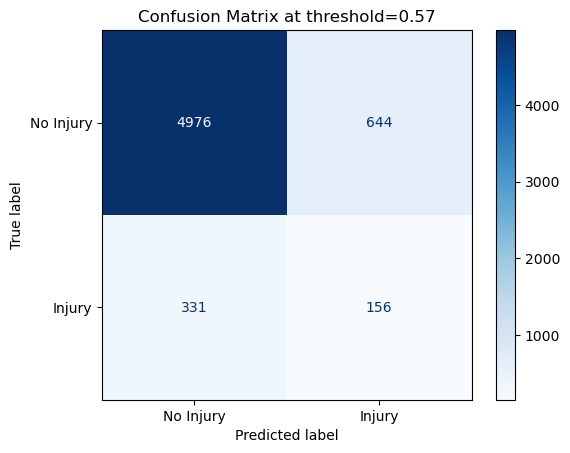

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion matrix at tuned threshold
cm = confusion_matrix(y_test, y_pred_thresh, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Injury", "Injury"])

print("Confusion Matrix:")
print(cm)

# Plot
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix at threshold={best_thresh:.2f}")
plt.show()


In [1]:
import pandas as pd

In [2]:
eve = pd.read_csv("everton.csv")

In [7]:
eve = eve.drop(columns=['Rk'])

In [8]:
eve

,Player,Date,Venue,Team,Opp,Comp,Result,Outcome,Start,Min,Pos.,14D Rolling Avg,7D Rolling Avg,Fixture Count 5D,Fixture Congestion Flag,Primary Position,Comp Intensity,Position Load Score
0,Abdoulaye Doucoure,2022-08-06,Home,Everton,Chelsea,Premier League,L 0-1,L,Y,90.0,MF,90.0,90.0,1.0,False,MF,5,5
1,Abdoulaye Doucoure,2022-08-13,Away,Everton,Aston Villa,Premier League,L 1-2,L,Y,34.0,MF,124.0,34.0,1.0,False,MF,5,5
2,Abdoulaye Doucoure,2022-08-20,NaN,Everton,NaN,NaN,NaN,NaN,NaN,0.0,MF,34.0,0.0,0.0,False,MF,1,5
3,Abdoulaye Doucoure,2022-08-27,NaN,Everton,NaN,NaN,NaN,NaN,NaN,0.0,MF,0.0,0.0,0.0,False,MF,1,5
4,Abdoulaye Doucoure,2022-08-30,NaN,Everton,NaN,NaN,NaN,NaN,NaN,0.0,MF,0.0,0.0,0.0,False,MF,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5353,Youssef Chermiti,2025-04-26,Away,Everton,Chelsea,Premier League,L 0-1,L,N,27.0,"FW,MF",27.0,27.0,1.0,False,FW,5,4
5354,Youssef Chermiti,2025-05-03,Home,Everton,Ipswich Town,Premier League,D 2-2,D,N,1.0,"FW,MF",28.0,1.0,1.0,False,FW,5,4
5355,Youssef Chermiti,2025-05-10,NaN,Everton,NaN,NaN,NaN,NaN,NaN,0.0,"FW,MF",1.0,0.0,0.0,False,FW,1,4
5356,Youssef Chermiti,2025-05-18,NaN,Everton,NaN,NaN,NaN,NaN,NaN,0.0,"FW,MF",0.0,0.0,0.0,False,FW,1,4


In [9]:
def get_season(date):
    year = date.year
    if date.month >= 8:  # from August, new season starts
        return f"{year}/{str(year+1)[-2:]}"
    else:  # Jan–July belong to the previous season
        return f"{year-1}/{str(year)[-2:]}"

In [14]:
eve.dtypes

Player                      object
Date                        object
Venue                       object
Team                        object
Opp                         object
Comp                        object
Result                      object
Outcome                     object
Start                       object
Min                        float64
Pos.                        object
14D Rolling Avg            float64
7D Rolling Avg             float64
Fixture Count 5D           float64
Fixture Congestion Flag       bool
Primary Position            object
Comp Intensity               int64
Position Load Score          int64
dtype: object

In [15]:
eve["Season"] = pd.to_datetime(eve["Date"]).apply(get_season)

In [17]:
eve.to_csv("everton.csv")

In [18]:
arsenal = pd.read_csv('arsenal_df.csv')
av_= pd.read_csv('av_df.csv')
man_u = pd.read_excel('Man_Utd_22-25.xlsx')

In [19]:
arsenal["Season"] = pd.to_datetime(arsenal["Date"]).apply(get_season)
av_["Season"] = pd.to_datetime(av_["Date"]).apply(get_season)
man_u["Season"] = pd.to_datetime(man_u["Date"]).apply(get_season)

In [20]:
arsenal.to_csv("arsenal_df.csv")
av_.to_csv('av_df.csv')
man_u.to_csv('man_u.csv')

In [29]:
arsenal

,Unnamed: 0,Player,Date,Rk,Venue,Team,Opp,Comp,Result,Outcome,...,Min,Pos.,14D Rolling Avg,7D Rolling Avg,Fixture Count 5D,Fixture Congestion Flag,Primary Position,Comp Intensity,Position Load Score,Season
0,0,Aaron Ramsdale,2022-08-05,2383.0,Away,Arsenal,Crystal Palace,Premier League,W 2-0,W,...,90.0,GK,90.0,90.0,1.0,False,GK,5,2,2022/23
1,1,Aaron Ramsdale,2022-08-13,2368.0,Home,Arsenal,Leicester City,Premier League,W 4-2,W,...,90.0,GK,180.0,90.0,1.0,False,GK,5,2,2022/23
2,2,Aaron Ramsdale,2022-08-20,2353.0,Away,Arsenal,Bournemouth,Premier League,W 3-0,W,...,90.0,GK,180.0,90.0,1.0,False,GK,5,2,2022/23
3,3,Aaron Ramsdale,2022-08-27,2337.0,Home,Arsenal,Fulham,Premier League,W 2-1,W,...,90.0,GK,180.0,90.0,1.0,False,GK,5,2,2022/23
4,4,Aaron Ramsdale,2022-08-31,2324.0,Home,Arsenal,Aston Villa,Premier League,W 2-1,W,...,90.0,GK,270.0,180.0,2.0,True,GK,5,2,2022/23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7150,7150,William Saliba,2025-05-03,69.0,Home,Arsenal,Bournemouth,Premier League,L 1-2,L,...,90.0,DF,360.0,180.0,2.0,True,DF,5,3,2024/25
7151,7151,William Saliba,2025-05-07,54.0,Away,Arsenal,Paris S-G,Champions League,L 1-2,L,...,90.0,DF,270.0,180.0,2.0,True,DF,5,3,2024/25
7152,7152,William Saliba,2025-05-11,39.0,Away,Arsenal,Liverpool,Premier League,D 2-2,D,...,90.0,DF,360.0,180.0,2.0,True,DF,5,3,2024/25
7153,7153,William Saliba,2025-05-18,25.0,Home,Arsenal,Newcastle Utd,Premier League,W 1-0,W,...,45.0,DF,225.0,45.0,1.0,False,DF,5,3,2024/25


In [48]:
arsenal_ = pd.read_excel('Arsenal_22-25.xlsx')


In [49]:
avil_= pd.read_excel('AV_22-25.xlsx')


In [50]:
evert = pd.read_excel('Everton_22-25.xlsx')

In [51]:
arsenal_ = arsenal_.drop(columns=['Rk'])

In [53]:
arsenal_['season'] = pd.to_datetime(arsenal_["Date"]).apply(get_season)

In [54]:
avil_['season'] = pd.to_datetime(avil_["Date"]).apply(get_season)

In [55]:
evert['season'] = pd.to_datetime(evert["Date"]).apply(get_season)

In [52]:
avil_ = avil_.drop(columns=['Rk'])
evert = evert.drop(columns=['Rk'])

In [56]:
arsenal_.to_csv("arsenal1.csv", index=False)
avil_.to_csv('av1.csv', index=False)
evert.to_csv('evert1.csv', index=False)

In [57]:
arsenal_

,Player,Date,Venue,Team,Opp,Comp,Result,Outcome,Start,Min,Pos.,season
0,Declan Rice,2025-05-25,Away,Arsenal,Southampton,Premier League,W 2-1,W,Y,90,MF,2024/25
1,Ben White,2025-05-25,Away,Arsenal,Southampton,Premier League,W 2-1,W,Y,90,DF,2024/25
2,Leandro Trossard,2025-05-25,Away,Arsenal,Southampton,Premier League,W 2-1,W,N,28,FW,2024/25
3,Gabriel Martinelli,2025-05-25,Away,Arsenal,Southampton,Premier League,W 2-1,W,Y,69,"FW,MF",2024/25
4,Oleksandr Zinchenko,2025-05-25,Away,Arsenal,Southampton,Premier League,W 2-1,W,Y,69,"DF,MF",2024/25
...,...,...,...,...,...,...,...,...,...,...,...,...
2389,Eddie Nketiah,2022-08-05,Away,Arsenal,Crystal Palace,Premier League,W 2-0,W,N,8,FW,2022/23
2390,Gabriel Jesus,2022-08-05,Away,Arsenal,Crystal Palace,Premier League,W 2-0,W,Y,82,FW,2022/23
2391,Bukayo Saka,2022-08-05,Away,Arsenal,Crystal Palace,Premier League,W 2-0,W,Y,90,FW,2022/23
2392,Granit Xhaka,2022-08-05,Away,Arsenal,Crystal Palace,Premier League,W 2-0,W,Y,90,MF,2022/23


In [58]:
arsenal

,Unnamed: 0,Player,Date,Rk,Venue,Team,Opp,Comp,Result,Outcome,...,Min,Pos.,14D Rolling Avg,7D Rolling Avg,Fixture Count 5D,Fixture Congestion Flag,Primary Position,Comp Intensity,Position Load Score,Season
0,0,Aaron Ramsdale,2022-08-05,2383.0,Away,Arsenal,Crystal Palace,Premier League,W 2-0,W,...,90.0,GK,90.0,90.0,1.0,False,GK,5,2,2022/23
1,1,Aaron Ramsdale,2022-08-13,2368.0,Home,Arsenal,Leicester City,Premier League,W 4-2,W,...,90.0,GK,180.0,90.0,1.0,False,GK,5,2,2022/23
2,2,Aaron Ramsdale,2022-08-20,2353.0,Away,Arsenal,Bournemouth,Premier League,W 3-0,W,...,90.0,GK,180.0,90.0,1.0,False,GK,5,2,2022/23
3,3,Aaron Ramsdale,2022-08-27,2337.0,Home,Arsenal,Fulham,Premier League,W 2-1,W,...,90.0,GK,180.0,90.0,1.0,False,GK,5,2,2022/23
4,4,Aaron Ramsdale,2022-08-31,2324.0,Home,Arsenal,Aston Villa,Premier League,W 2-1,W,...,90.0,GK,270.0,180.0,2.0,True,GK,5,2,2022/23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7150,7150,William Saliba,2025-05-03,69.0,Home,Arsenal,Bournemouth,Premier League,L 1-2,L,...,90.0,DF,360.0,180.0,2.0,True,DF,5,3,2024/25
7151,7151,William Saliba,2025-05-07,54.0,Away,Arsenal,Paris S-G,Champions League,L 1-2,L,...,90.0,DF,270.0,180.0,2.0,True,DF,5,3,2024/25
7152,7152,William Saliba,2025-05-11,39.0,Away,Arsenal,Liverpool,Premier League,D 2-2,D,...,90.0,DF,360.0,180.0,2.0,True,DF,5,3,2024/25
7153,7153,William Saliba,2025-05-18,25.0,Home,Arsenal,Newcastle Utd,Premier League,W 1-0,W,...,45.0,DF,225.0,45.0,1.0,False,DF,5,3,2024/25


In [59]:
man_u

,Rk,Player,Date,Age,Team,Venue,Opp,Comp,Result,Start,Min,Gls,Ast,G+A,G-PK,PK,PKatt,PKm,Pos.,Season
0,927,Aaron Wan-Bissaka,2024-05-25,26,Manchester Utd,Neutral,Manchester City,FA Cup,W 2-1,Y,90.0,0,0,0,0,0,0,0,DF,2023/24
1,944,Aaron Wan-Bissaka,2024-05-19,26,Manchester Utd,Away,Brighton,Premier League,W 2-0,Y,90.0,0,0,0,0,0,0,0,DF,2023/24
2,960,Aaron Wan-Bissaka,2024-05-15,26,Manchester Utd,Home,Newcastle Utd,Premier League,W 3-2,Y,90.0,0,0,0,0,0,0,0,DF,2023/24
3,978,Aaron Wan-Bissaka,2024-05-12,26,Manchester Utd,Home,Arsenal,Premier League,L 0-1,Y,86.0,0,0,0,0,0,0,0,DF,2023/24
4,993,Aaron Wan-Bissaka,2024-05-06,26,Manchester Utd,Away,Crystal Palace,Premier League,L 0-4,Y,90.0,0,0,0,0,0,0,0,DF,2023/24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2637,2157,Wout Weghorst,2023-02-01,30,Manchester Utd,Home,Nott'ham Forest,EFL Cup,W 2-0,Y,62.0,0,0,0,0,0,0,0,FW,2022/23
2638,2173,Wout Weghorst,2023-01-28,30,Manchester Utd,Home,Reading,FA Cup,W 3-1,Y,72.0,0,0,0,0,0,0,0,FW,2022/23
2639,2190,Wout Weghorst,2023-01-25,30,Manchester Utd,Away,Nott'ham Forest,EFL Cup,W 3-0,Y,84.0,1,0,1,1,0,0,0,FW,2022/23
2640,2203,Wout Weghorst,2023-01-22,30,Manchester Utd,Away,Arsenal,Premier League,L 2-3,Y,90.0,0,0,0,0,0,0,0,"FW,MF",2022/23


In [ ]:
man_u = man_u.drop(columns=['Rk',' '])